# ODE integration sandbox

Purpose now: run ODE integration with the best-known strategy, compare PySR vs linear regression for one marker, and visualise why one wins (dt fit vs integrated trajectories). The grid/appendix remains if you want to explore further, but the top cells focus on best-strategy side-by-side plots and metrics.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

try:
    from scipy.integrate import solve_ivp
except Exception:
    solve_ivp = None

# Optional diffrax/JAX for Tsit5
try:
    import jax.numpy as jnp
    from diffrax import AutoTsit5, ODETerm, SaveAt, diffeqsolve
except Exception:
    jnp = AutoTsit5 = ODETerm = SaveAt = diffeqsolve = None

plt.style.use('seaborn-v0_8')

In [3]:
# --- configuration ---
SUMMARY_PATH = Path("../data/experimental/functional_groups/outputs/reports/summary/functional_group_summary.csv")
DATASET_PATHS = {
    "per_minute": Path("../data/experimental/processed/functional_groups/functional_groups_per_minute_fit.csv"),
    "snapshot": Path("../data/experimental/processed/functional_groups/functional_groups_fit_snapshot.csv"),
}

# choose marker/mode to inspect
DATASET_MODE = "per_minute"  # per_minute or snapshot
MARKER = "DYRK3"

# best-found integration strategy (from previous grid)
BEST_STRATEGY = {
    "solver": "euler",  # lightweight and matched the top integ_med we saw
    "solver_kwargs": {"rtol": 1e-3, "atol": 1e-5},
    "state_clamp": (0.0, 1e6),
    "deriv_clip": 1e6,
}

# models to compare side-by-side under the best strategy
COMPARE_MODELS = ("PySR", "Linear Regression")
MODEL = COMPARE_MODELS[0]  # legacy default for older cells
MAX_COMPARE_BINS = 6  # limit plots to first N GFP bins to keep figures readable

# expose defaults for helper functions/older cells
DEFAULT_SOLVER = BEST_STRATEGY["solver"]
DEFAULT_SOLVER_KWARGS = BEST_STRATEGY["solver_kwargs"]
STATE_CLAMP = BEST_STRATEGY["state_clamp"]
DERIV_CLIP = BEST_STRATEGY["deriv_clip"]

MEASURED_TIMEPOINTS = [0.0, 5.0, 10.0, 15.0, 30.0, 60.0]
EXCLUDE_COLUMNS = {"p-ERK1-2_dt", "p-MEK1-2_dt", "marker", "timepoint", "GFP_bin"}


In [4]:
# --- helpers mirroring the pipeline ---
def sanitize_feature_names(columns):
    renamed = []
    for col in columns:
        clean = col.replace("-", "_").replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
        if clean and clean[0].isdigit():
            clean = f"f_{clean}"
        renamed.append(clean)
    return renamed

def prepare_dataset(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.replace("_fit$", "", regex=True)
    target_col = sanitize_feature_names(["p-ERK1-2_dt"])[0]
    candidate_cols = [c for c in df.columns if c not in EXCLUDE_COLUMNS]
    df.rename(columns=dict(zip(candidate_cols, sanitize_feature_names(candidate_cols))), inplace=True)
    df[target_col] = pd.to_numeric(df.get("p-ERK1-2_dt", df.get(target_col)), errors="coerce")
    if "marker" in df.columns:
        df["marker"] = df["marker"].astype(str)
    if "GFP_bin" in df.columns:
        df["GFP_bin"] = pd.to_numeric(df["GFP_bin"], errors="coerce")
    if "timepoint" in df.columns:
        df["timepoint"] = pd.to_numeric(df["timepoint"], errors="coerce")
    return df, target_col

def load_formula(summary_path, marker, model, dataset_mode):
    summary = pd.read_csv(summary_path)
    subset = summary[(summary["group_name"] == marker) & (summary["model"] == model)]
    if "dataset_mode" in subset.columns:
        subset = subset[subset["dataset_mode"] == dataset_mode]
    if subset.empty:
        raise ValueError(f"No rows for marker={marker}, model={model}, mode={dataset_mode}")
    formula = subset.iloc[0]["formula"]
    if not isinstance(formula, str) or formula == "N/A":
        raise ValueError("Formula missing for selection")
    return formula

def evaluate_formula(formula, features):
    expr = sp.sympify(formula)
    symbols = sorted({str(s) for s in expr.free_symbols})
    for m in symbols:
        if m not in features.columns:
            features[m] = 0.0
    func = sp.lambdify(symbols, expr, "numpy")
    arrays = [features[s].to_numpy(dtype=float) for s in symbols] if symbols else []
    vals = func(*arrays) if symbols else np.full(len(features), float(expr))
    vals = np.asarray(vals, dtype=float).reshape(-1)
    vals[~np.isfinite(vals)] = np.nan
    return vals

def build_rhs(formula, backend="numpy"):
    expr = sp.sympify(formula)
    symbols = sorted(expr.free_symbols, key=lambda s: s.name)
    func = sp.lambdify(symbols, expr, backend)
    return func, [s.name for s in symbols]


In [5]:
# --- integration utilities ---
def compute_dt_r2(sub, preds, target_col, measured_timepoints, dataset_mode):
    y_true = pd.to_numeric(sub[target_col], errors="coerce").to_numpy()
    y_pred = np.asarray(preds, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if dataset_mode == "per_minute":
        mask &= np.isin(sub["timepoint"].to_numpy(), measured_timepoints)
    if mask.sum() < 2:
        return np.nan
    num = np.sum((y_true[mask] - y_pred[mask]) ** 2)
    den = np.sum((y_true[mask] - np.mean(y_true[mask])) ** 2)
    return float(1.0 - num / den) if den > 0 else np.nan

def integrate_bin(bin_df, symbol_names, p_symbol, rhs_fn, solver, solver_kwargs, target_col, dataset_mode, measured_timepoints, state_clamp, deriv_clip):
    g = bin_df.sort_values("timepoint").copy()
    t = g["timepoint"].to_numpy(dtype=float)
    obs_dt = g[target_col].to_numpy(dtype=float)
    if "p_ERK1_2" in g.columns:
        obs_pe_arr = pd.to_numeric(g["p_ERK1_2"], errors="coerce").to_numpy(dtype=float)
    elif "p-ERK1-2" in g.columns:
        obs_pe_arr = pd.to_numeric(g["p-ERK1-2"], errors="coerce").to_numpy(dtype=float)
    else:
        obs_pe_arr = np.full_like(t, np.nan)
    mask = np.isfinite(t) & np.isfinite(obs_dt)
    t, obs_dt, obs_pe_arr = t[mask], obs_dt[mask], obs_pe_arr[mask]
    if len(t) < 2:
        return None
    order = np.argsort(t)
    t, obs_dt, obs_pe_arr = t[order], obs_dt[order], obs_pe_arr[order]

    feature_arrays = {}
    for name in symbol_names:
        if name == p_symbol:
            continue
        if name in g.columns:
            vals = pd.to_numeric(g.loc[g.index[mask], name], errors="coerce").to_numpy(dtype=float)[order]
        else:
            vals = np.zeros_like(t)
        feature_arrays[name] = vals

    def _rhs_scalar(ti, yi):
        vals = []
        for name in symbol_names:
            if name == p_symbol:
                vals.append(float(np.clip(yi, state_clamp[0], state_clamp[1])))
            else:
                arr = feature_arrays[name]
                vals.append(float(np.interp(ti, t, arr)))
        try:
            deriv = float(rhs_fn(*vals))
        except Exception:
            deriv = np.nan
        if not np.isfinite(deriv):
            deriv = np.nan
        return float(np.clip(deriv, -deriv_clip, deriv_clip))

    init_p = obs_pe_arr[0] if np.isfinite(obs_pe_arr[0]) else 0.0
    integ = np.full_like(t, np.nan, dtype=float)
    dt_preds = np.full_like(t, np.nan, dtype=float)
    integ[0] = np.clip(init_p, state_clamp[0], state_clamp[1])

    if solver.startswith("solve_ivp") and solve_ivp is None:
        raise ImportError("scipy not available; install scipy or switch to euler")

    if solver.startswith("solve_ivp") and solve_ivp is not None:
        method = "RK45" if solver == "solve_ivp_rk45" else "Radau" if solver == "solve_ivp_radau" else "BDF"
        sol = solve_ivp(lambda tau, y: _rhs_scalar(tau, y[0]), (t[0], t[-1]), [integ[0]], t_eval=t, method=method, **solver_kwargs)
        integ = sol.y[0]
        dt_preds[:-1] = [_rhs_scalar(ti, pi) for ti, pi in zip(t[:-1], integ[:-1])]
    elif solver == "diffrax_tsit5" and jnp is not None and AutoTsit5 is not None and ODETerm is not None:
        t_jnp = jnp.asarray(t, dtype=float)
        feat_jnp = {k: jnp.asarray(v, dtype=float) for k, v in feature_arrays.items()}
        def _ode_fn(ti, yi, _args):
            vals = []
            for name in symbol_names:
                if name == p_symbol:
                    vals.append(jnp.clip(yi[0], state_clamp[0], state_clamp[1]))
                else:
                    vals.append(jnp.interp(ti, t_jnp, feat_jnp[name]))
            deriv = rhs_fn(*vals)
            deriv = jnp.clip(deriv, -deriv_clip, deriv_clip)
            return jnp.asarray([deriv], dtype=float)
        sol = diffeqsolve(
            ODETerm(_ode_fn),
            AutoTsit5(),
            t0=t_jnp[0],
            t1=t_jnp[-1],
            y0=jnp.asarray([integ[0]], dtype=float),
            dt0=None,
            saveat=SaveAt(ts=t_jnp),
        )
        integ = np.asarray(sol.ys[:, 0], dtype=float)
        dt_preds[:-1] = [_rhs_scalar(ti, pi) for ti, pi in zip(t[:-1], integ[:-1])]
    else:  # Euler
        for j in range(len(t) - 1):
            dt = t[j + 1] - t[j]
            deriv = _rhs_scalar(t[j], integ[j])
            dt_preds[j] = deriv
            if np.isfinite(deriv) and np.isfinite(integ[j]):
                integ[j + 1] = np.clip(integ[j] + dt * deriv, state_clamp[0], state_clamp[1])

    mask_eval = np.isfinite(obs_pe_arr) & np.isfinite(integ)
    if dataset_mode == "per_minute":
        mask_eval &= np.isin(t, measured_timepoints)
    integ_r2 = np.nan
    if mask_eval.sum() > 1:
        try:
            integ_r2 = float(np.corrcoef(obs_pe_arr[mask_eval], integ[mask_eval])[0, 1] ** 2)
        except Exception:
            integ_r2 = np.nan

    return {
        "t": t,
        "obs_dt": obs_dt,
        "obs_pe": obs_pe_arr,
        "integ": integ,
        "dt_rhs": dt_preds,
        "integ_r2": integ_r2,
        "gfp_bin": g["GFP_bin"].iloc[0],
    }

def run_single_marker(dataset_mode, marker, model, solver, solver_kwargs, state_clamp, deriv_clip, measured_timepoints, quiet=False):
    dataset_path = DATASET_PATHS[dataset_mode]
    df, target_col = prepare_dataset(dataset_path)
    formula = load_formula(SUMMARY_PATH, marker, model, dataset_mode)
    if not quiet:
        print(f"Using formula ({model}, {dataset_mode}): {formula}")
    rhs_fn, symbols = build_rhs(formula, backend="numpy")
    p_symbol = sanitize_feature_names(["p-ERK1-2"])[0]
    sub = df[df["marker"] == marker].dropna(subset=[target_col, "timepoint", "GFP_bin"])
    features = sub[[c for c in sub.columns if c not in EXCLUDE_COLUMNS and c != target_col]].copy()
    dt_preds = evaluate_formula(formula, features)
    sub = sub.assign(__y_pred_dt=dt_preds)

    dt_r2 = compute_dt_r2(sub, dt_preds, target_col, measured_timepoints, dataset_mode)
    if not quiet:
        print(f"dt R2 (formula only): {dt_r2:.4f}")

    bin_results = []
    for gfp in sorted(sub["GFP_bin"].dropna().unique()):
        res = integrate_bin(
            sub[sub["GFP_bin"] == gfp],
            symbols,
            p_symbol,
            rhs_fn,
            solver,
            solver_kwargs,
            target_col,
            dataset_mode,
            measured_timepoints,
            state_clamp,
            deriv_clip,
        )
        if res is not None:
            bin_results.append(res)
    integ_r2_vals = [r["integ_r2"] for r in bin_results if np.isfinite(r["integ_r2"])]
    integ_med = float(np.nanmedian(integ_r2_vals)) if integ_r2_vals else np.nan
    if not quiet:
        print(f"Integrated R2 median across bins: {integ_med:.4f}")

    metrics = {
        "dt_r2": dt_r2,
        "integ_r2_median": integ_med,
        "bin_results": bin_results,
        "target_col": target_col,
        "formula": formula,
    }
    return sub, bin_results, target_col, metrics


In [6]:
# --- run best strategy for both models ---
best = BEST_STRATEGY
single_runs = {}
for model in COMPARE_MODELS:
    sub_df_model, bin_results_model, target_col_model, metrics_model = run_single_marker(
        DATASET_MODE,
        MARKER,
        model,
        best["solver"],
        best["solver_kwargs"],
        best["state_clamp"],
        best["deriv_clip"],
        MEASURED_TIMEPOINTS,
        quiet=True,
    )
    single_runs[model] = {
        "sub": sub_df_model,
        "bin_results": bin_results_model,
        "target_col": target_col_model,
        "metrics": metrics_model,
    }

summary_rows = []
for model, payload in single_runs.items():
    m = payload["metrics"]
    summary_rows.append({
        "model": model,
        "solver": best["solver"],
        "rtol": best["solver_kwargs"].get("rtol"),
        "atol": best["solver_kwargs"].get("atol"),
        "state_clamp": best["state_clamp"],
        "deriv_clip": best["deriv_clip"],
        "dt_r2": m["dt_r2"],
        "integ_r2_median": m["integ_r2_median"],
        "bins": len(payload["bin_results"]),
    })
summary_df = pd.DataFrame(summary_rows).sort_values("integ_r2_median", ascending=False)
display(summary_df)
print("Ran best strategy:", best.get("label", best["solver"]))

# keep defaults for downstream plots (use the first model in COMPARE_MODELS)
default_model = COMPARE_MODELS[0]
sub_df = single_runs[default_model]["sub"]
bin_results = single_runs[default_model]["bin_results"]
target_col = single_runs[default_model]["target_col"]
single_metrics = single_runs[default_model]["metrics"]
sub_df.head()


FileNotFoundError: [Errno 2] No such file or directory: '../data/experimental/functional_groups/outputs/reports/summary/functional_group_summary.csv'

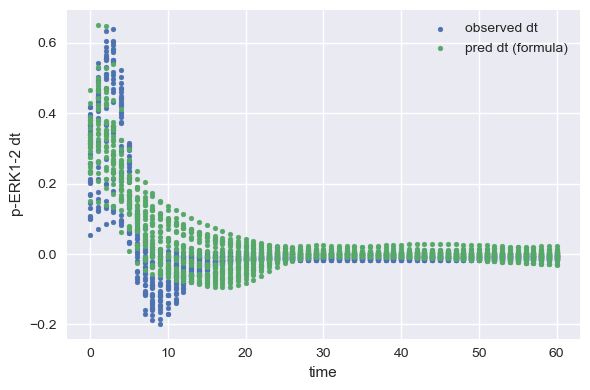

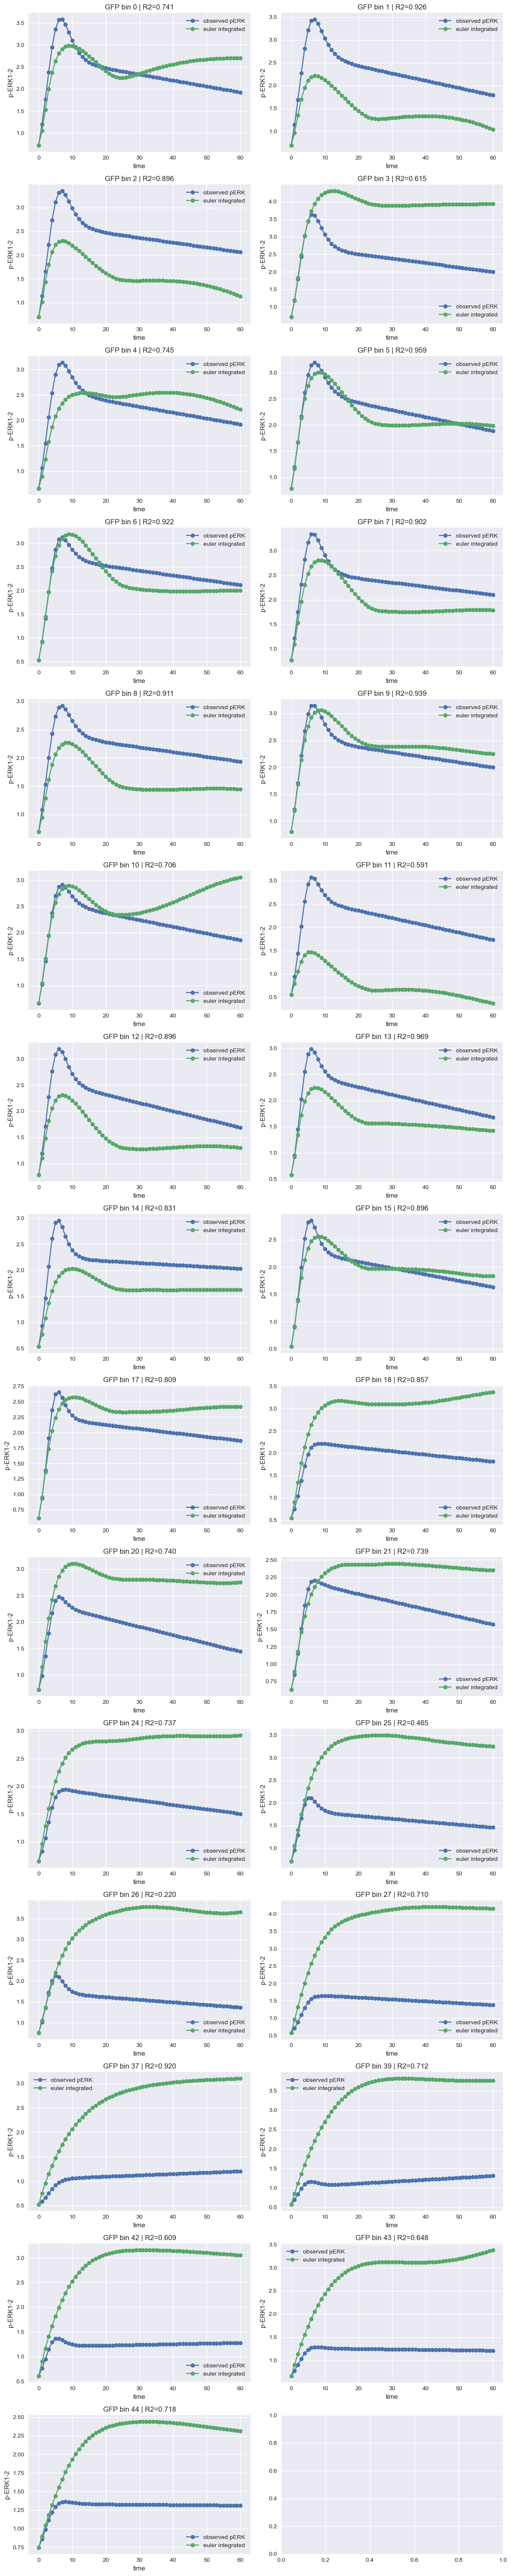

{'dt_r2': 0.6363237719959839,
 'integ_r2_median': 0.7452710758940437,
 'bin_results': [{'t': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
          13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
          26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
          39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
          52., 53., 54., 55., 56., 57., 58., 59., 60.]),
   'obs_dt': array([ 0.4186107 ,  0.52841559,  0.60519199,  0.60625925,  0.50401195,
           0.315348  ,  0.10245577, -0.0667305 , -0.15997745, -0.18574271,
          -0.17084888, -0.13981802, -0.10745247, -0.08013487, -0.05935223,
          -0.04444572, -0.03412763, -0.02714223, -0.02247909, -0.01939408,
          -0.01736494, -0.01603527, -0.01516607, -0.01459878, -0.01422891,
          -0.01398791, -0.01383096, -0.01372876, -0.01366224, -0.01361894,
          -0.01359075, -0.01357241, -0.01356048, -0.01355271, -0.01354765,
          -0.01354

In [ ]:
# --- quick plots for the last run ---
def plot_dt_overlay(sub, target_col):
    plt.figure(figsize=(6, 4))
    plt.scatter(sub["timepoint"], sub[target_col], s=12, label="observed dt")
    plt.scatter(sub["timepoint"], sub["__y_pred_dt"], s=12, label="pred dt (formula)")
    plt.xlabel("time")
    plt.ylabel("p-ERK1-2 dt")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_integration(bin_results, solver_label="solver"):
    n = len(bin_results)
    if n == 0:
        return
    cols = min(2, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), squeeze=False)
    for ax, res in zip(axes.ravel(), bin_results):
        ax.plot(res["t"], res["obs_pe"], "o-", label="observed pERK")
        ax.plot(res["t"], res["integ"], "o-", label=f"{solver_label} integrated")
        ax.set_title(f"GFP bin {res['gfp_bin']} | R2={res['integ_r2']:.3f}")
        ax.set_xlabel("time")
        ax.set_ylabel("p-ERK1-2")
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_dt_overlay(sub_df, target_col)
plot_integration(bin_results, solver_label=DEFAULT_SOLVER)
single_metrics

model,Linear Regression,PySR,delta_LR_minus_PySR
gfp_bin,,,
26,0.836947,0.219885,0.617062
25,0.971437,0.465319,0.506119
42,0.984698,0.609141,0.375558
11,0.944278,0.590816,0.353462
3,0.947018,0.614981,0.332037
10,0.958713,0.706327,0.252386
21,0.989568,0.738690,0.250878
4,0.991379,0.745271,0.246108
0,0.981077,0.741286,0.239790


PySR formula:
  p_p90RSK*(p_MKK3_6 - 1.3552803)*(p_p90RSK - 0.90025306/p_RAF)

Linear Regression formula:
  0.0502 -0.0881 * GFP -0.3609 * p_ERK1_2 -0.0419 * p_ERK1_2_min +0.9313 * p_MEK1_2 -0.0196 * p_MEK1_2_min -0.6144 * p_RAF -0.1336 * p_p90RSK -0.1103 * p_MAPKAPK2 -0.1706 * p_PDK1 -0.0479 * p_MKK3_6



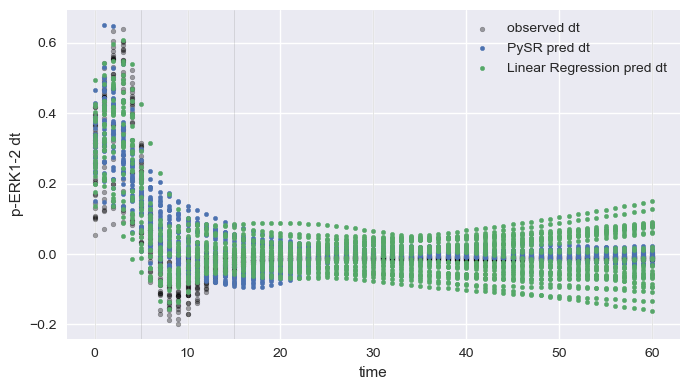

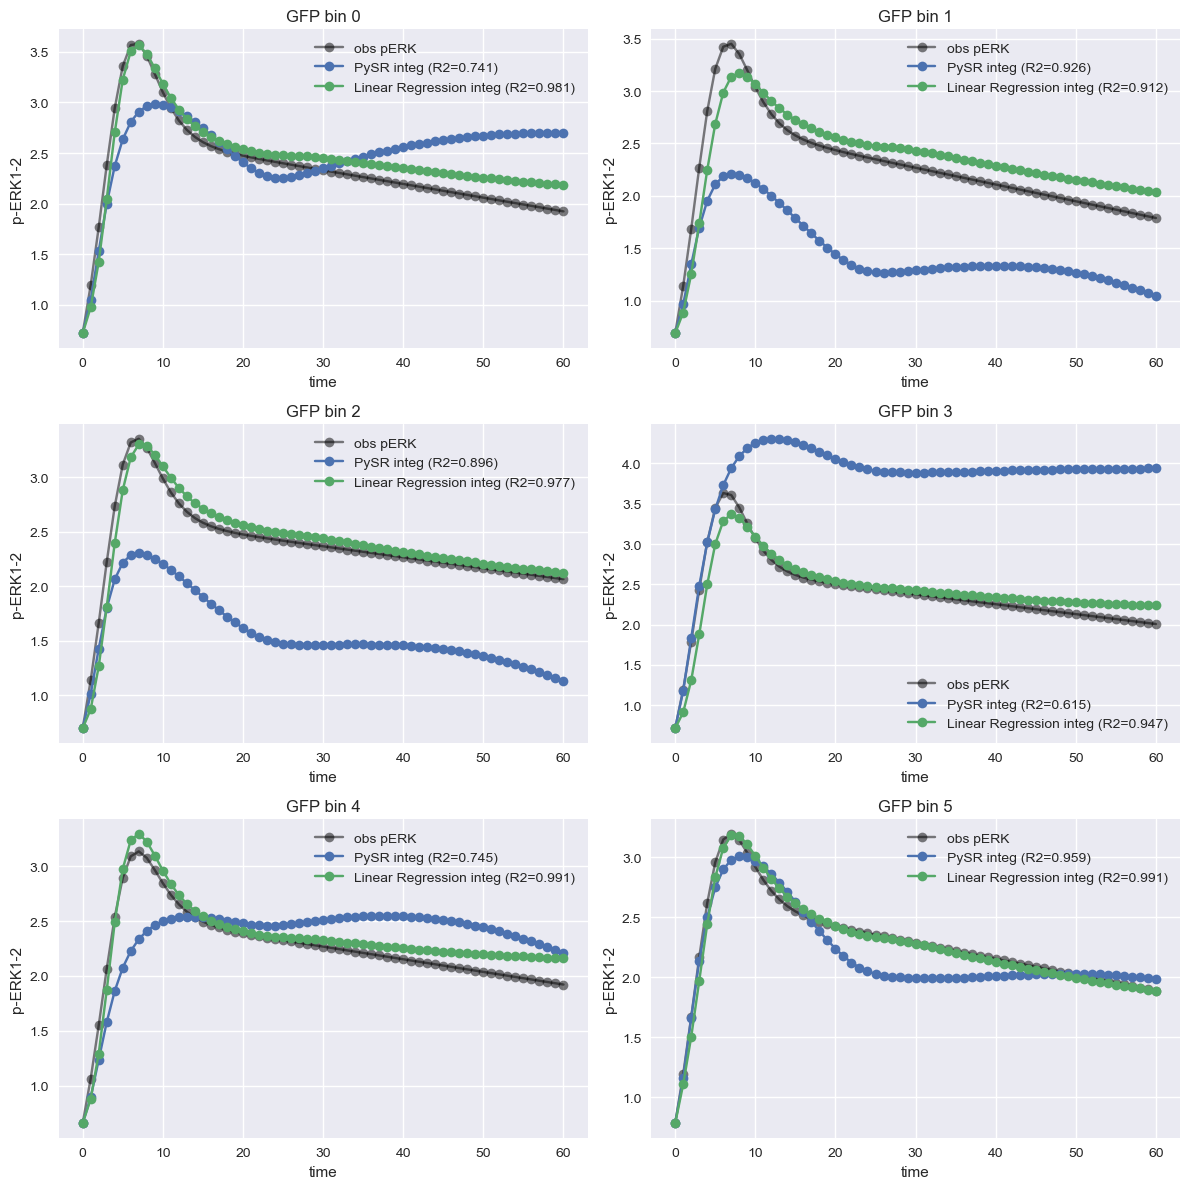

In [ ]:
# --- compare PySR vs Linear Regression under best strategy ---
import numpy as np


def _bin_r2_df(single_runs):
    rows = []
    for model, payload in single_runs.items():
        for res in payload['bin_results']:
            rows.append({'model': model, 'gfp_bin': res['gfp_bin'], 'integ_r2': res['integ_r2']})
    return pd.DataFrame(rows)


bin_r2_df = _bin_r2_df(single_runs)
if not bin_r2_df.empty:
    pivot = bin_r2_df.pivot(index='gfp_bin', columns='model', values='integ_r2')
    if set(COMPARE_MODELS).issubset(pivot.columns):
        pivot['delta_LR_minus_PySR'] = pivot.get('Linear Regression') - pivot.get('PySR')
        display(pivot.sort_values('delta_LR_minus_PySR', ascending=False).head(10))


def plot_dt_compare(single_runs, measured_timepoints=None):
    base_model = COMPARE_MODELS[0]
    base = single_runs[base_model]
    tgt = base['target_col']
    plt.figure(figsize=(7, 4))
    plt.scatter(base['sub']['timepoint'], base['sub'][tgt], s=12, c='k', alpha=0.35, label='observed dt')
    for model, payload in single_runs.items():
        plt.scatter(payload['sub']['timepoint'], payload['sub']['__y_pred_dt'], s=10, label=f"{model} pred dt")
    if measured_timepoints is not None:
        for t in measured_timepoints:
            plt.axvline(t, color='gray', lw=0.5, alpha=0.3)
    plt.xlabel('time')
    plt.ylabel('p-ERK1-2 dt')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_integration_compare(single_runs, max_bins=MAX_COMPARE_BINS):
    if not single_runs:
        print('No runs available')
        return
    bin_maps = {m: {res['gfp_bin']: res for res in payload['bin_results']} for m, payload in single_runs.items()}
    common_bins = set.intersection(*[set(b.keys()) for b in bin_maps.values()]) if bin_maps else set()
    if not common_bins:
        print('No overlapping GFP bins across models')
        return
    bins_to_plot = sorted(common_bins)[:max_bins]
    cols = min(2, len(bins_to_plot))
    rows = int(np.ceil(len(bins_to_plot) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), squeeze=False)
    for ax, b in zip(axes.ravel(), bins_to_plot):
        obs = bin_maps[COMPARE_MODELS[0]][b]
        ax.plot(obs['t'], obs['obs_pe'], 'o-', color='k', alpha=0.5, label='obs pERK')
        for model in COMPARE_MODELS:
            res = bin_maps[model][b]
            ax.plot(res['t'], res['integ'], 'o-', label=f"{model} integ (R2={res['integ_r2']:.3f})")
        ax.set_title(f"GFP bin {b}")
        ax.set_xlabel('time')
        ax.set_ylabel('p-ERK1-2')
        ax.legend()
    plt.tight_layout()
    plt.show()

# print formulas for quick inspection
for model in COMPARE_MODELS:
    formula = single_runs[model]['metrics'].get('formula')
    print(f"{model} formula:\n  {formula}\n")

plot_dt_compare(single_runs, measured_timepoints=MEASURED_TIMEPOINTS)
plot_integration_compare(single_runs, max_bins=MAX_COMPARE_BINS)


In [ ]:
# --- diagnostics: why PySR vs Linear Regression differ ---
import sympy as sp


def baseline_integrate_obs(sub, target_col):
    rows = []
    bins = sorted(sub['GFP_bin'].dropna().unique())
    integ_r2_vals = []
    for b in bins:
        g = sub[sub['GFP_bin'] == b].copy()
        g.sort_values('timepoint', inplace=True)
        t = g['timepoint'].to_numpy(dtype=float)
        dt_obs = g[target_col].to_numpy(dtype=float)
        if 'p_ERK1_2' in g.columns:
            obs_pe = g['p_ERK1_2'].to_numpy(dtype=float)
        elif 'p-ERK1-2' in g.columns:
            obs_pe = g['p-ERK1-2'].to_numpy(dtype=float)
        else:
            obs_pe = None
        mask = np.isfinite(t) & np.isfinite(dt_obs)
        if mask.sum() < 2:
            continue
        t, dt_obs = t[mask], dt_obs[mask]
        if obs_pe is not None:
            obs_pe = obs_pe[mask]
        order = np.argsort(t)
        t, dt_obs = t[order], dt_obs[order]
        integ = np.full_like(t, np.nan, dtype=float)
        integ[0] = obs_pe[0] if obs_pe is not None and np.isfinite(obs_pe[0]) else 0.0
        for j in range(len(t) - 1):
            dt = t[j + 1] - t[j]
            if np.isfinite(dt_obs[j]) and np.isfinite(integ[j]):
                integ[j + 1] = integ[j] + dt * dt_obs[j]
        mask_eval = np.isfinite(integ)
        if obs_pe is not None:
            mask_eval &= np.isfinite(obs_pe)
            if mask_eval.sum() > 1:
                try:
                    r2 = np.corrcoef(obs_pe[mask_eval], integ[mask_eval])[0, 1] ** 2
                    integ_r2_vals.append(float(r2))
                except Exception:
                    pass
    return float(np.nanmedian(integ_r2_vals)) if integ_r2_vals else np.nan


def summarize_dt(single_runs):
    rows = []
    for model, payload in single_runs.items():
        dt = payload['sub']['__y_pred_dt'].to_numpy(dtype=float)
        rows.append({
            'model': model,
            'dt_min': np.nanmin(dt),
            'dt_max': np.nanmax(dt),
            'dt_med': np.nanmedian(dt),
            'dt_nan_frac': float(np.mean(~np.isfinite(dt))),
        })
    return pd.DataFrame(rows)


def partial_wrt_p(formula, sub):
    p_sym = sanitize_feature_names(['p-ERK1-2'])[0]
    expr = sp.sympify(formula)
    try:
        d_expr = sp.diff(expr, sp.Symbol(p_sym))
    except Exception:
        return None, None
    symbols = sorted(d_expr.free_symbols, key=lambda s: s.name)
    func = sp.lambdify(symbols, d_expr, 'numpy')
    feature_df = sub[[c for c in sub.columns if c not in EXCLUDE_COLUMNS]].copy()
    for s in symbols:
        name = s.name
        if name not in feature_df:
            feature_df[name] = 0.0
    arrays = [pd.to_numeric(feature_df[s.name], errors='coerce').to_numpy(dtype=float) for s in symbols]
    vals = func(*arrays)
    vals = np.asarray(vals, dtype=float).reshape(-1)
    return d_expr, {
        'dexpr': d_expr,
        'p_grad_min': np.nanmin(vals),
        'p_grad_max': np.nanmax(vals),
        'p_grad_med': np.nanmedian(vals),
    }


# baseline with observed dt (upper bound on integration quality)
base_model = COMPARE_MODELS[0]
base_sub = single_runs[base_model]['sub']
base_target = single_runs[base_model]['target_col']
baseline_r2 = baseline_integrate_obs(base_sub, base_target)
print(f"Baseline integrate observed dt (median R2): {baseline_r2:.4f}")

# dt summary per model
summary_dt = summarize_dt(single_runs)
display(summary_dt)

# partial derivative wrt p_ERK per model
rows_grad = []
for model in COMPARE_MODELS:
    formula = single_runs[model]['metrics'].get('formula')
    if formula:
        d_expr, stats = partial_wrt_p(formula, base_sub)
        if stats:
            stats.update({'model': model, 'formula': formula, 'd_expr': str(d_expr)})
            rows_grad.append(stats)
        else:
            rows_grad.append({'model': model, 'formula': formula, 'd_expr': None, 'p_grad_min': np.nan, 'p_grad_max': np.nan, 'p_grad_med': np.nan})
    else:
        rows_grad.append({'model': model, 'formula': None, 'd_expr': None, 'p_grad_min': np.nan, 'p_grad_max': np.nan, 'p_grad_med': np.nan})
if rows_grad:
    grad_df = pd.DataFrame(rows_grad)
    display(grad_df[['model','p_grad_min','p_grad_med','p_grad_max']])
    print("d/dp expressions:")
    for _, row in grad_df.iterrows():
        print(f"{row['model']}: {row['d_expr']}")

# simple heuristic: check for p in denominator or negative powers
for model in COMPARE_MODELS:
    formula = single_runs[model]['metrics'].get('formula')
    if not formula:
        continue
    has_div = f"/{sanitize_feature_names(['p-ERK1-2'])[0]}" in formula or '**-' in formula
    print(f"{model}: potential stiffness? {has_div} | formula: {formula}")


Baseline integrate observed dt (median R2): 0.9786


,model,dt_min,dt_max,dt_med,dt_nan_frac
0,PySR,-0.094599,0.651074,0.000385,0.0
1,Linear Regression,-0.160545,0.609115,0.001245,0.0


,model,p_grad_min,p_grad_med,p_grad_max
0,PySR,0.0000,0.0000,0.0000
1,Linear Regression,-0.3609,-0.3609,-0.3609


d/dp expressions:
PySR: 0
Linear Regression: -0.360900000000000
PySR: potential stiffness? False | formula: p_p90RSK*(p_MKK3_6 - 1.3552803)*(p_p90RSK - 0.90025306/p_RAF)
Linear Regression: potential stiffness? False | formula: 0.0502 -0.0881 * GFP -0.3609 * p_ERK1_2 -0.0419 * p_ERK1_2_min +0.9313 * p_MEK1_2 -0.0196 * p_MEK1_2_min -0.6144 * p_RAF -0.1336 * p_p90RSK -0.1103 * p_MAPKAPK2 -0.1706 * p_PDK1 -0.0479 * p_MKK3_6


In [ ]:
# --- define a grid of integration strategies (100 combos) ---
tol_grid = [
    (1e-2, 1e-4),
    (5e-3, 5e-5),
    (1e-3, 1e-5),
    (1e-4, 1e-6),
    (1e-5, 1e-7),
]
state_clamps = [
    (0.0, 1e6),
    (0.0, 1e5),
]
deriv_clips = [1e4, 1e6]
solvers = ["euler", "solve_ivp_rk45", "solve_ivp_radau", "solve_ivp_bdf", "diffrax_tsit5"]
STRATEGIES = []
for solver in solvers:
    for rtol, atol in tol_grid:
        for clamp in state_clamps:
            for dclip in deriv_clips:
                STRATEGIES.append({
                    "label": f"{solver}|rtol={rtol:g},atol={atol:g}|clamp=({clamp[0]:g},{clamp[1]:g})|clip={dclip:g}",
                    "solver": solver,
                    "solver_kwargs": {"rtol": rtol, "atol": atol},
                    "state_clamp": clamp,
                    "deriv_clip": dclip,
                })
print(f"Configured {len(STRATEGIES)} strategies")
STRATEGIES[:3]

Configured 100 strategies


[{'label': 'euler|rtol=0.01,atol=0.0001|clamp=(0,1e+06)|clip=10000',
  'solver': 'euler',
  'solver_kwargs': {'rtol': 0.01, 'atol': 0.0001},
  'state_clamp': (0.0, 1000000.0),
  'deriv_clip': 10000.0},
 {'label': 'euler|rtol=0.01,atol=0.0001|clamp=(0,1e+06)|clip=1e+06',
  'solver': 'euler',
  'solver_kwargs': {'rtol': 0.01, 'atol': 0.0001},
  'state_clamp': (0.0, 1000000.0),
  'deriv_clip': 1000000.0},
 {'label': 'euler|rtol=0.01,atol=0.0001|clamp=(0,100000)|clip=10000',
  'solver': 'euler',
  'solver_kwargs': {'rtol': 0.01, 'atol': 0.0001},
  'state_clamp': (0.0, 100000.0),
  'deriv_clip': 10000.0}]

In [ ]:
# --- run the strategy grid ---
grid_results = []
for strat in STRATEGIES:
    try:
        _, bin_res, target_col_grid, metrics = run_single_marker(
            DATASET_MODE,
            MARKER,
            MODEL,
            strat["solver"],
            strat["solver_kwargs"],
            strat["state_clamp"],
            strat["deriv_clip"],
            MEASURED_TIMEPOINTS,
            quiet=True,
        )
        grid_results.append({
            "label": strat["label"],
            "solver": strat["solver"],
            "rtol": strat["solver_kwargs"].get("rtol"),
            "atol": strat["solver_kwargs"].get("atol"),
            "dt_r2": metrics["dt_r2"],
            "integ_r2_median": metrics["integ_r2_median"],
            "bin_results": bin_res,
            "target_col": target_col_grid,
            "error": None,
        })
    except Exception as exc:
        grid_results.append({
            "label": strat["label"],
            "solver": strat["solver"],
            "rtol": strat["solver_kwargs"].get("rtol"),
            "atol": strat["solver_kwargs"].get("atol"),
            "dt_r2": np.nan,
            "integ_r2_median": np.nan,
            "bin_results": [],
            "target_col": None,
            "error": str(exc),
        })
successes = [r for r in grid_results if r["error"] is None]
print(f"Completed {len(grid_results)} strategies; successes: {len(successes)}")
successes[:3]

Completed 100 strategies; successes: 60


[{'label': 'euler|rtol=0.01,atol=0.0001|clamp=(0,1e+06)|clip=10000',
  'solver': 'euler',
  'rtol': 0.01,
  'atol': 0.0001,
  'dt_r2': 0.6363237719959839,
  'integ_r2_median': 0.7452710758940437,
  'bin_results': [{'t': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
           13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
           26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
           39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
           52., 53., 54., 55., 56., 57., 58., 59., 60.]),
    'obs_dt': array([ 0.4186107 ,  0.52841559,  0.60519199,  0.60625925,  0.50401195,
            0.315348  ,  0.10245577, -0.0667305 , -0.15997745, -0.18574271,
           -0.17084888, -0.13981802, -0.10745247, -0.08013487, -0.05935223,
           -0.04444572, -0.03412763, -0.02714223, -0.02247909, -0.01939408,
           -0.01736494, -0.01603527, -0.01516607, -0.01459878, -0.01422891,
           -0.01398791, -0.01383

,label,solver,rtol,atol,dt_r2,integ_r2_median,target_col,error
20,"solve_ivp_rk45|rtol=0.01,atol=0.0001|clamp=(0,...",solve_ivp_rk45,0.0100,0.000100,0.636324,0.779834,p_ERK1_2_dt,None
21,"solve_ivp_rk45|rtol=0.01,atol=0.0001|clamp=(0,...",solve_ivp_rk45,0.0100,0.000100,0.636324,0.779834,p_ERK1_2_dt,None
22,"solve_ivp_rk45|rtol=0.01,atol=0.0001|clamp=(0,...",solve_ivp_rk45,0.0100,0.000100,0.636324,0.779834,p_ERK1_2_dt,None
23,"solve_ivp_rk45|rtol=0.01,atol=0.0001|clamp=(0,...",solve_ivp_rk45,0.0100,0.000100,0.636324,0.779834,p_ERK1_2_dt,None
26,"solve_ivp_rk45|rtol=0.005,atol=5e-05|clamp=(0,...",solve_ivp_rk45,0.0050,0.000050,0.636324,0.776797,p_ERK1_2_dt,None
24,"solve_ivp_rk45|rtol=0.005,atol=5e-05|clamp=(0,...",solve_ivp_rk45,0.0050,0.000050,0.636324,0.776797,p_ERK1_2_dt,None
25,"solve_ivp_rk45|rtol=0.005,atol=5e-05|clamp=(0,...",solve_ivp_rk45,0.0050,0.000050,0.636324,0.776797,p_ERK1_2_dt,None
27,"solve_ivp_rk45|rtol=0.005,atol=5e-05|clamp=(0,...",solve_ivp_rk45,0.0050,0.000050,0.636324,0.776797,p_ERK1_2_dt,None
35,"solve_ivp_rk45|rtol=0.0001,atol=1e-06|clamp=(0...",solve_ivp_rk45,0.0001,0.000001,0.636324,0.776566,p_ERK1_2_dt,None
34,"solve_ivp_rk45|rtol=0.0001,atol=1e-06|clamp=(0...",solve_ivp_rk45,0.0001,0.000001,0.636324,0.776566,p_ERK1_2_dt,None


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_96230/2943501867.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


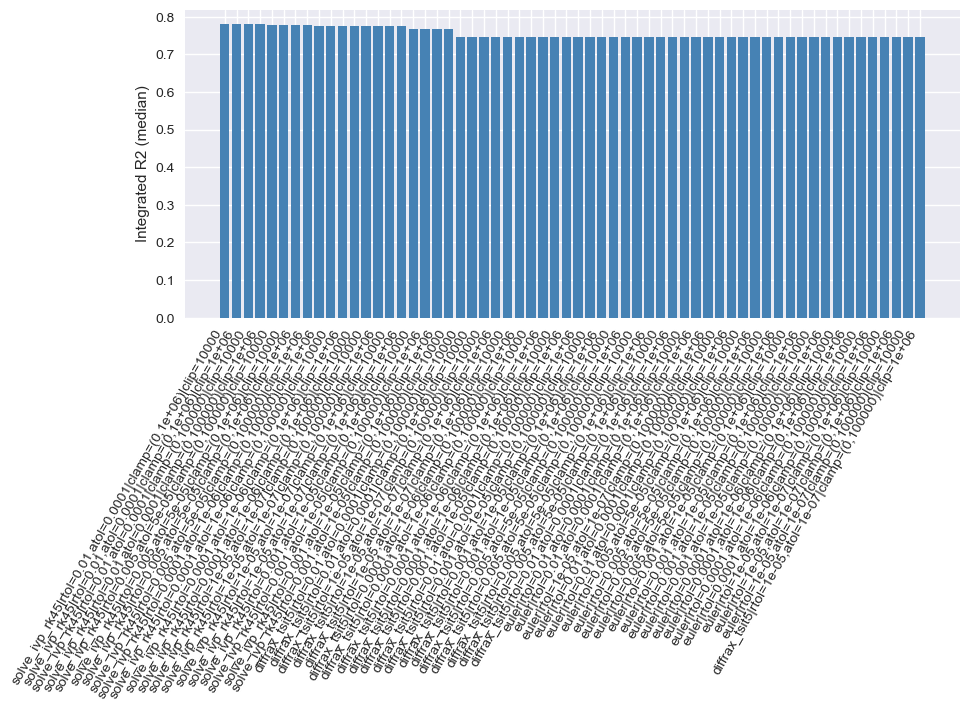

/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_96230/2943501867.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


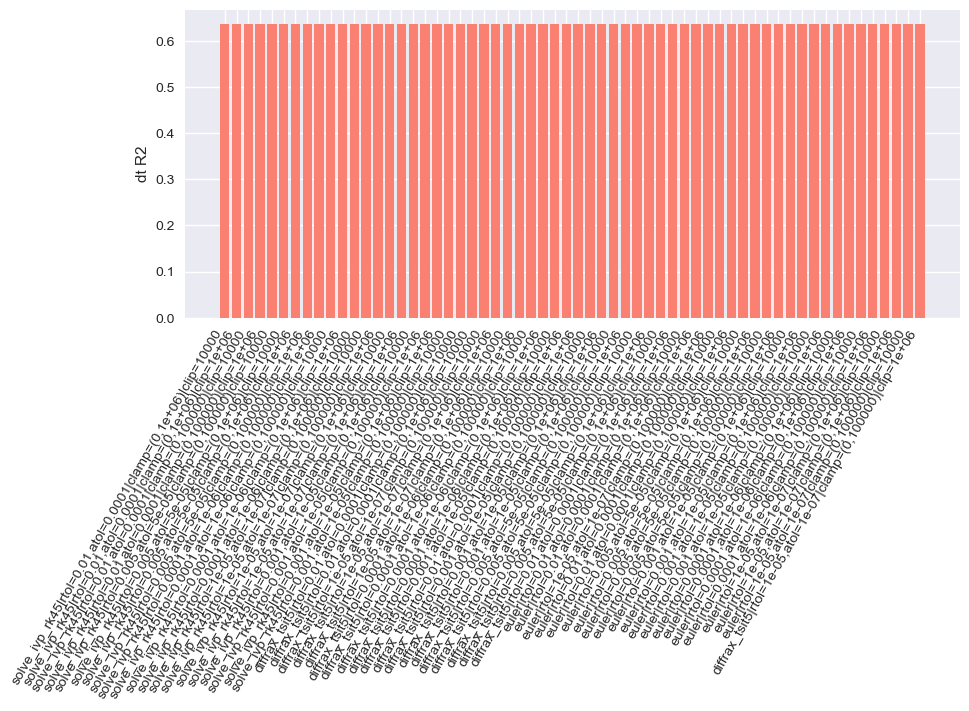

Best strategy: solve_ivp_rk45|rtol=0.01,atol=0.0001|clamp=(0,1e+06)|clip=10000 | integ_med=0.7798 | dt_r2=0.6363


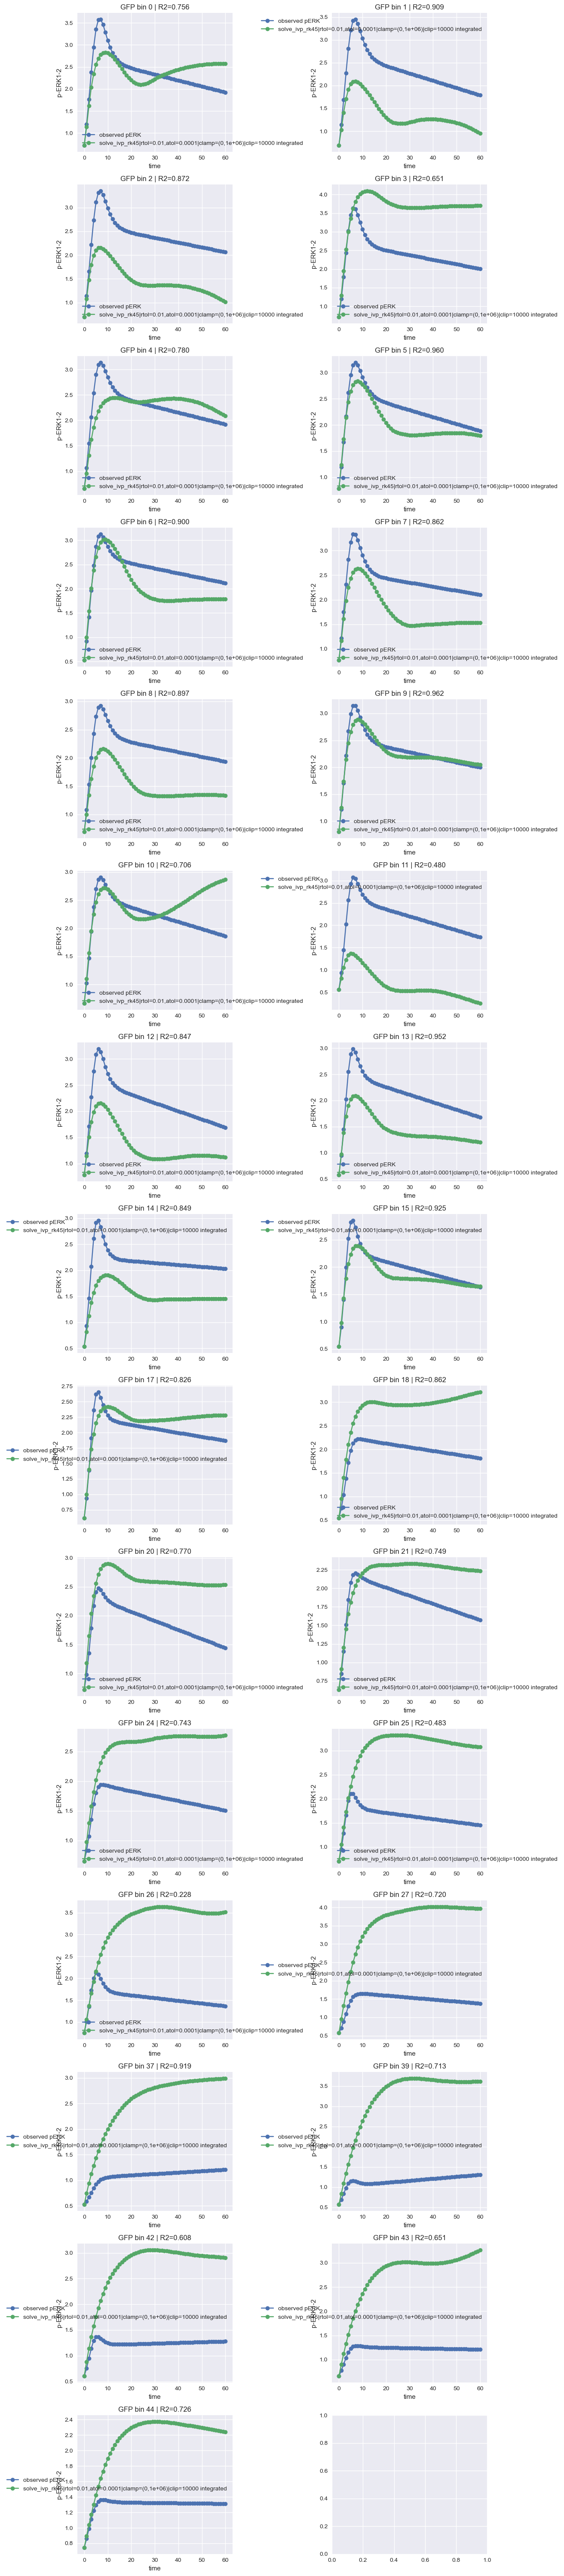

In [ ]:
# --- visualise strategy performance ---
import pandas as pd

success_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("bin_results",)} for r in successes
])
if not success_df.empty:
    display(success_df.sort_values("integ_r2_median", ascending=False).head(10))

    plt.figure(figsize=(10, 4))
    ordered = success_df.sort_values("integ_r2_median", ascending=False)
    plt.bar(range(len(ordered)), ordered["integ_r2_median"], color="steelblue")
    plt.xticks(range(len(ordered)), ordered["label"], rotation=60, ha="right")
    plt.ylabel("Integrated R2 (median)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.bar(range(len(ordered)), ordered["dt_r2"], color="salmon")
    plt.xticks(range(len(ordered)), ordered["label"], rotation=60, ha="right")
    plt.ylabel("dt R2")
    plt.tight_layout()
    plt.show()

    best = ordered.iloc[0]
    best_label = best["label"]
    print(f"Best strategy: {best_label} | integ_med={best['integ_r2_median']:.4f} | dt_r2={best['dt_r2']:.4f}")
    best_bins = next(r for r in successes if r["label"] == best_label)["bin_results"]
    plot_integration(best_bins, solver_label=best_label)
else:
    print("No successful strategies to display")

Dataset=per_minute, marker=ERBB2, model=PySR, GFP_bin=45
dt R² (PySR vs true dt, on true states): 0.4668
traj R² (direct dt integration)       : -79.7530
traj R² (Euler RHS path)              : -0.3018
traj R² (ODE solver RHS path)         : -0.1692
traj R² (GT dt integrated)            : -0.7150


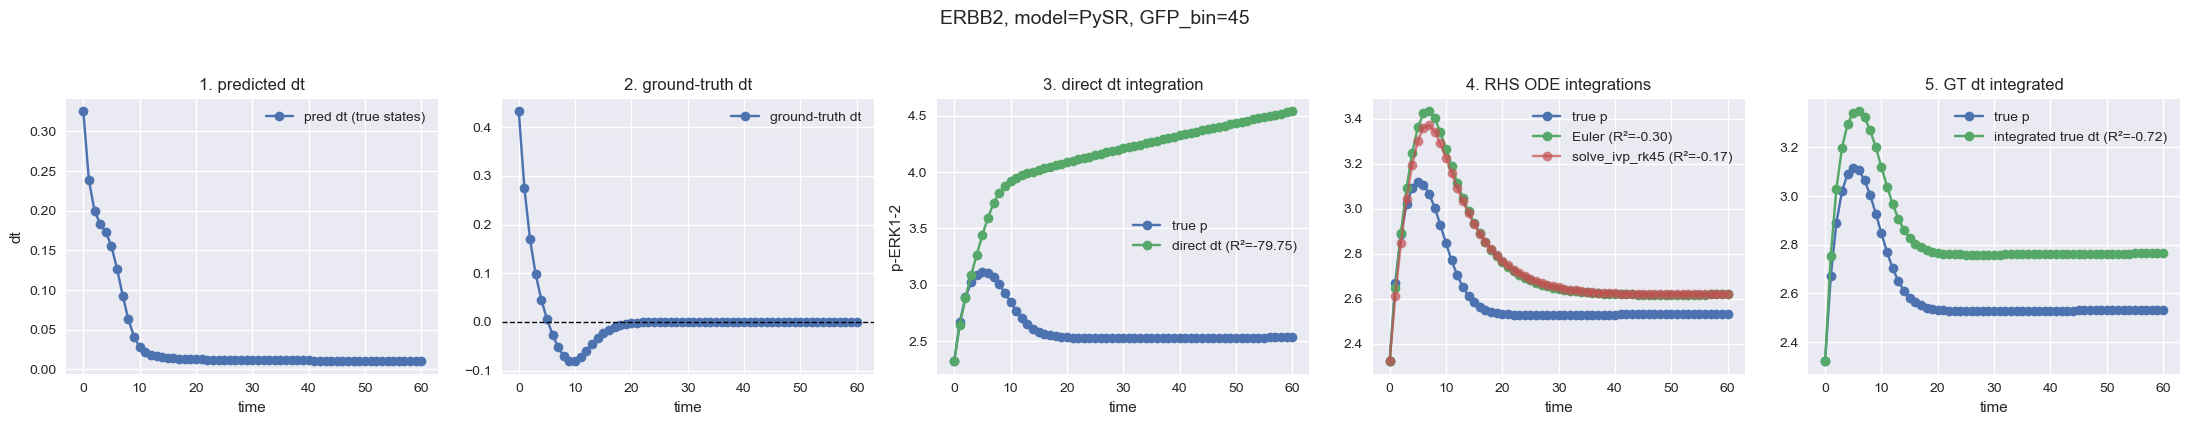

Dataset=per_minute, marker=ERBB2, model=Linear Regression, GFP_bin=45
dt R² (PySR vs true dt, on true states): 0.3797
traj R² (direct dt integration)       : -20.4534
traj R² (Euler RHS path)              : 0.4548
traj R² (ODE solver RHS path)         : 0.5538
traj R² (GT dt integrated)            : -0.7150


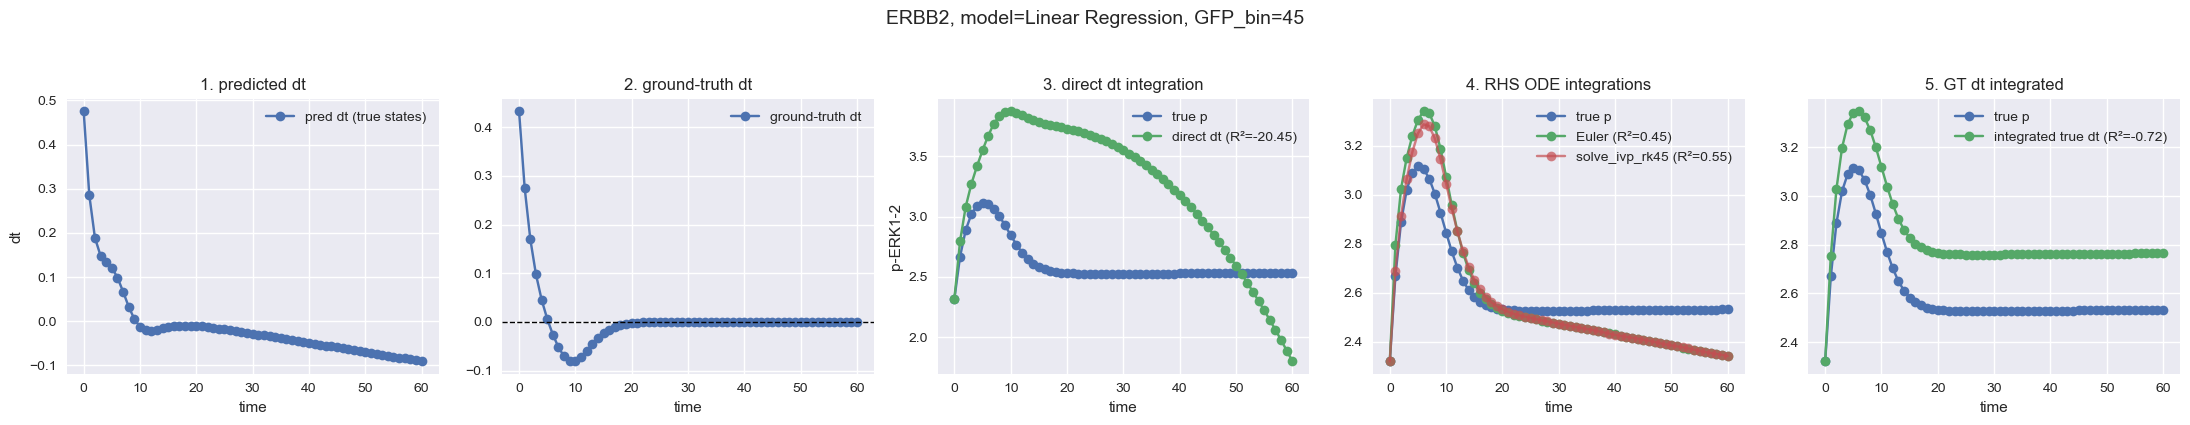

In [ ]:
    # === Debug cell (fixed): compare dt models and integrations for one GFP bin ===
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd


    def debug_bin_fixed(
        gfp_bin=0,
        dataset_mode=DATASET_MODE,
        marker=MARKER,
        model=MODEL,
        solver_ode="solve_ivp_rk45",
        solver_ode_kwargs=DEFAULT_SOLVER_KWARGS,
        state_clamp=STATE_CLAMP,
        deriv_clip=DERIV_CLIP,
        measured_timepoints=MEASURED_TIMEPOINTS,
        ):
        print(f"Dataset={dataset_mode}, marker={marker}, model={model}, GFP_bin={gfp_bin}")

        # 1) Run with Euler (this gives us: per-bin integration + RHS along the Euler path)
        sub_euler, bins_euler, target_col, metrics_euler = run_single_marker(
            dataset_mode,
            marker,
            model,
            "euler",
            {},
            state_clamp,
            deriv_clip,
            measured_timepoints,
            quiet=True,
        )

        # 2) Run with a proper ODE solver (RK45 by default)
        _, bins_ode, target_col2, metrics_ode = run_single_marker(
            dataset_mode,
            marker,
            model,
            solver_ode,
            solver_ode_kwargs,
            state_clamp,
            deriv_clip,
            measured_timepoints,
            quiet=True,
        )
        assert target_col == target_col2

        # --- Grab bin-specific stuff from the per-bin dictionaries (Euler + ODE) ---
        try:
            res_euler = next(r for r in bins_euler if r["gfp_bin"] == gfp_bin)
            res_ode   = next(r for r in bins_ode   if r["gfp_bin"] == gfp_bin)
        except StopIteration:
            raise ValueError(f"GFP_bin {gfp_bin} not found in results")

        t       = res_euler["t"]
        dt_true_bin = res_euler["obs_dt"]          # ground-truth dt (numeric)
        p_true_bin  = res_euler["obs_pe"]          # ground-truth p
        p_euler     = res_euler["integ"]           # Euler integration of RHS
        p_ode       = res_ode["integ"]             # solve_ivp (or other) integration of RHS
        dt_rhs_path = res_euler["dt_rhs"]          # RHS evaluated along EULER path (for curiosity)

        # --- Grab the ORIGINAL dt predictions on the TRUE states for this bin ---
        sub_bin = (
            sub_euler[sub_euler["GFP_bin"] == gfp_bin]
            .sort_values("timepoint")
            .reset_index(drop=True)
        )
        t_gt       = sub_bin["timepoint"].to_numpy(dtype=float)
        p_true_gt  = pd.to_numeric(sub_bin["p_ERK1_2"], errors="coerce").to_numpy()
        dt_true_gt = pd.to_numeric(sub_bin[target_col], errors="coerce").to_numpy()
        dt_pred_gt = pd.to_numeric(sub_bin["__y_pred_dt"], errors="coerce").to_numpy()

        # Safety check: times should match
        if not np.allclose(t_gt, t):
            print("WARNING: time grid mismatch between sub_bin and bin_results; using t_gt for direct dt integration.")
        t_use = t_gt

        # --- Helper: simple forward update on the measurement grid from GIVEN dt_hat ---
        def forward_update(p0, dt_hat, t_vec):
            p_rec = np.full_like(dt_hat, np.nan, dtype=float)
            p_rec[0] = p0
            for i in range(len(t_vec) - 1):
                dt_step = t_vec[i+1] - t_vec[i]
                if np.isfinite(dt_hat[i]) and np.isfinite(p_rec[i]):
                    p_rec[i+1] = p_rec[i] + dt_step * dt_hat[i]
            return p_rec

        # 3) Direct dt integration on TRUE states using dt_pred_gt
        p_direct = forward_update(
            p_true_gt[0] if np.isfinite(p_true_gt[0]) else 0.0,
            dt_pred_gt,
            t_use,
        )

        # 4) Integrate ground-truth dt (sanity check)
        p_gt = forward_update(
            p_true_gt[0] if np.isfinite(p_true_gt[0]) else 0.0,
            dt_true_gt,
            t_use,
        )

        # --- R² helper ---
        def r2(y, yhat):
            mask = np.isfinite(y) & np.isfinite(yhat)
            if mask.sum() < 2:
                return np.nan
            num = np.sum((y[mask] - yhat[mask])**2)
            den = np.sum((y[mask] - y[mask].mean())**2)
            return 1.0 - num / den if den > 0 else np.nan

        # Metrics
        dt_r2 = r2(dt_true_gt, dt_pred_gt)          # *proper* dt R² on true states
        r2_direct = r2(p_true_gt, p_direct)         # direct dt integration vs true p
        r2_euler  = r2(p_true_bin, p_euler)         # Euler path vs true p
        r2_ode    = r2(p_true_bin, p_ode)           # ODE solver vs true p
        r2_gt     = r2(p_true_gt, p_gt)             # integrated true dt vs true p

        print(f"dt R² (PySR vs true dt, on true states): {dt_r2:.4f}")
        print(f"traj R² (direct dt integration)       : {r2_direct:.4f}")
        print(f"traj R² (Euler RHS path)              : {r2_euler:.4f}")
        print(f"traj R² (ODE solver RHS path)         : {r2_ode:.4f}")
        print(f"traj R² (GT dt integrated)            : {r2_gt:.4f}")

        # --- Plots: match your five-column layout, but with correct dt in col 1 ---
        fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharex=True)

        # 1. predicted dt on TRUE states (plus RHS-path dt as dashed, just to see drift)
        axes[0].plot(t_use, dt_pred_gt, "o-", label="pred dt (true states)")
        # axes[0].plot(t, dt_rhs_path, "o--", alpha=0.4, label="pred dt (Euler path)")
        axes[0].set_title("1. predicted dt")
        axes[0].set_xlabel("time")
        axes[0].set_ylabel("dt")
        axes[0].legend()

        # 2. ground-truth dt
        axes[1].plot(t_use, dt_true_gt, "o-", label="ground-truth dt")
        axes[1].axhline(0.0, ls="--", linewidth=1, color="k")
        axes[1].set_title("2. ground-truth dt")
        axes[1].set_xlabel("time")
        axes[1].legend()

        # 3. direct dt integration (your "simple forward update")
        axes[2].plot(t_use, p_true_gt,  "o-", label="true p")
        axes[2].plot(t_use, p_direct,   "o-", label=f"direct dt (R²={r2_direct:.2f})")
        axes[2].set_title("3. direct dt integration")
        axes[2].set_xlabel("time")
        axes[2].set_ylabel("p-ERK1-2")
        axes[2].legend()

        # 4. ODE solver integration (RHS evaluated along evolving p)
        axes[3].plot(t, p_true_bin, "o-", label="true p")
        axes[3].plot(t, p_euler,    "o-", label=f"Euler (R²={r2_euler:.2f})")
        axes[3].plot(t, p_ode,      "o-", label=f"{solver_ode} (R²={r2_ode:.2f})", alpha=0.7)
        axes[3].set_title("4. RHS ODE integrations")
        axes[3].set_xlabel("time")
        axes[3].legend()

        # 5. Ground-truth dt integrated
        axes[4].plot(t_use, p_true_gt, "o-", label="true p")
        axes[4].plot(t_use, p_gt,      "o-", label=f"integrated true dt (R²={r2_gt:.2f})")
        axes[4].set_title("5. GT dt integrated")
        axes[4].set_xlabel("time")
        axes[4].legend()

        plt.suptitle(f"{marker}, model={model}, GFP_bin={gfp_bin}", y=1.05, fontsize=14)
        plt.tight_layout()
        plt.show()

    # Example usage (same as before, but now fixed):
    for res in ['PySR', 'Linear Regression']:
        debug_bin_fixed(gfp_bin=45, model=res, marker='ERBB2')

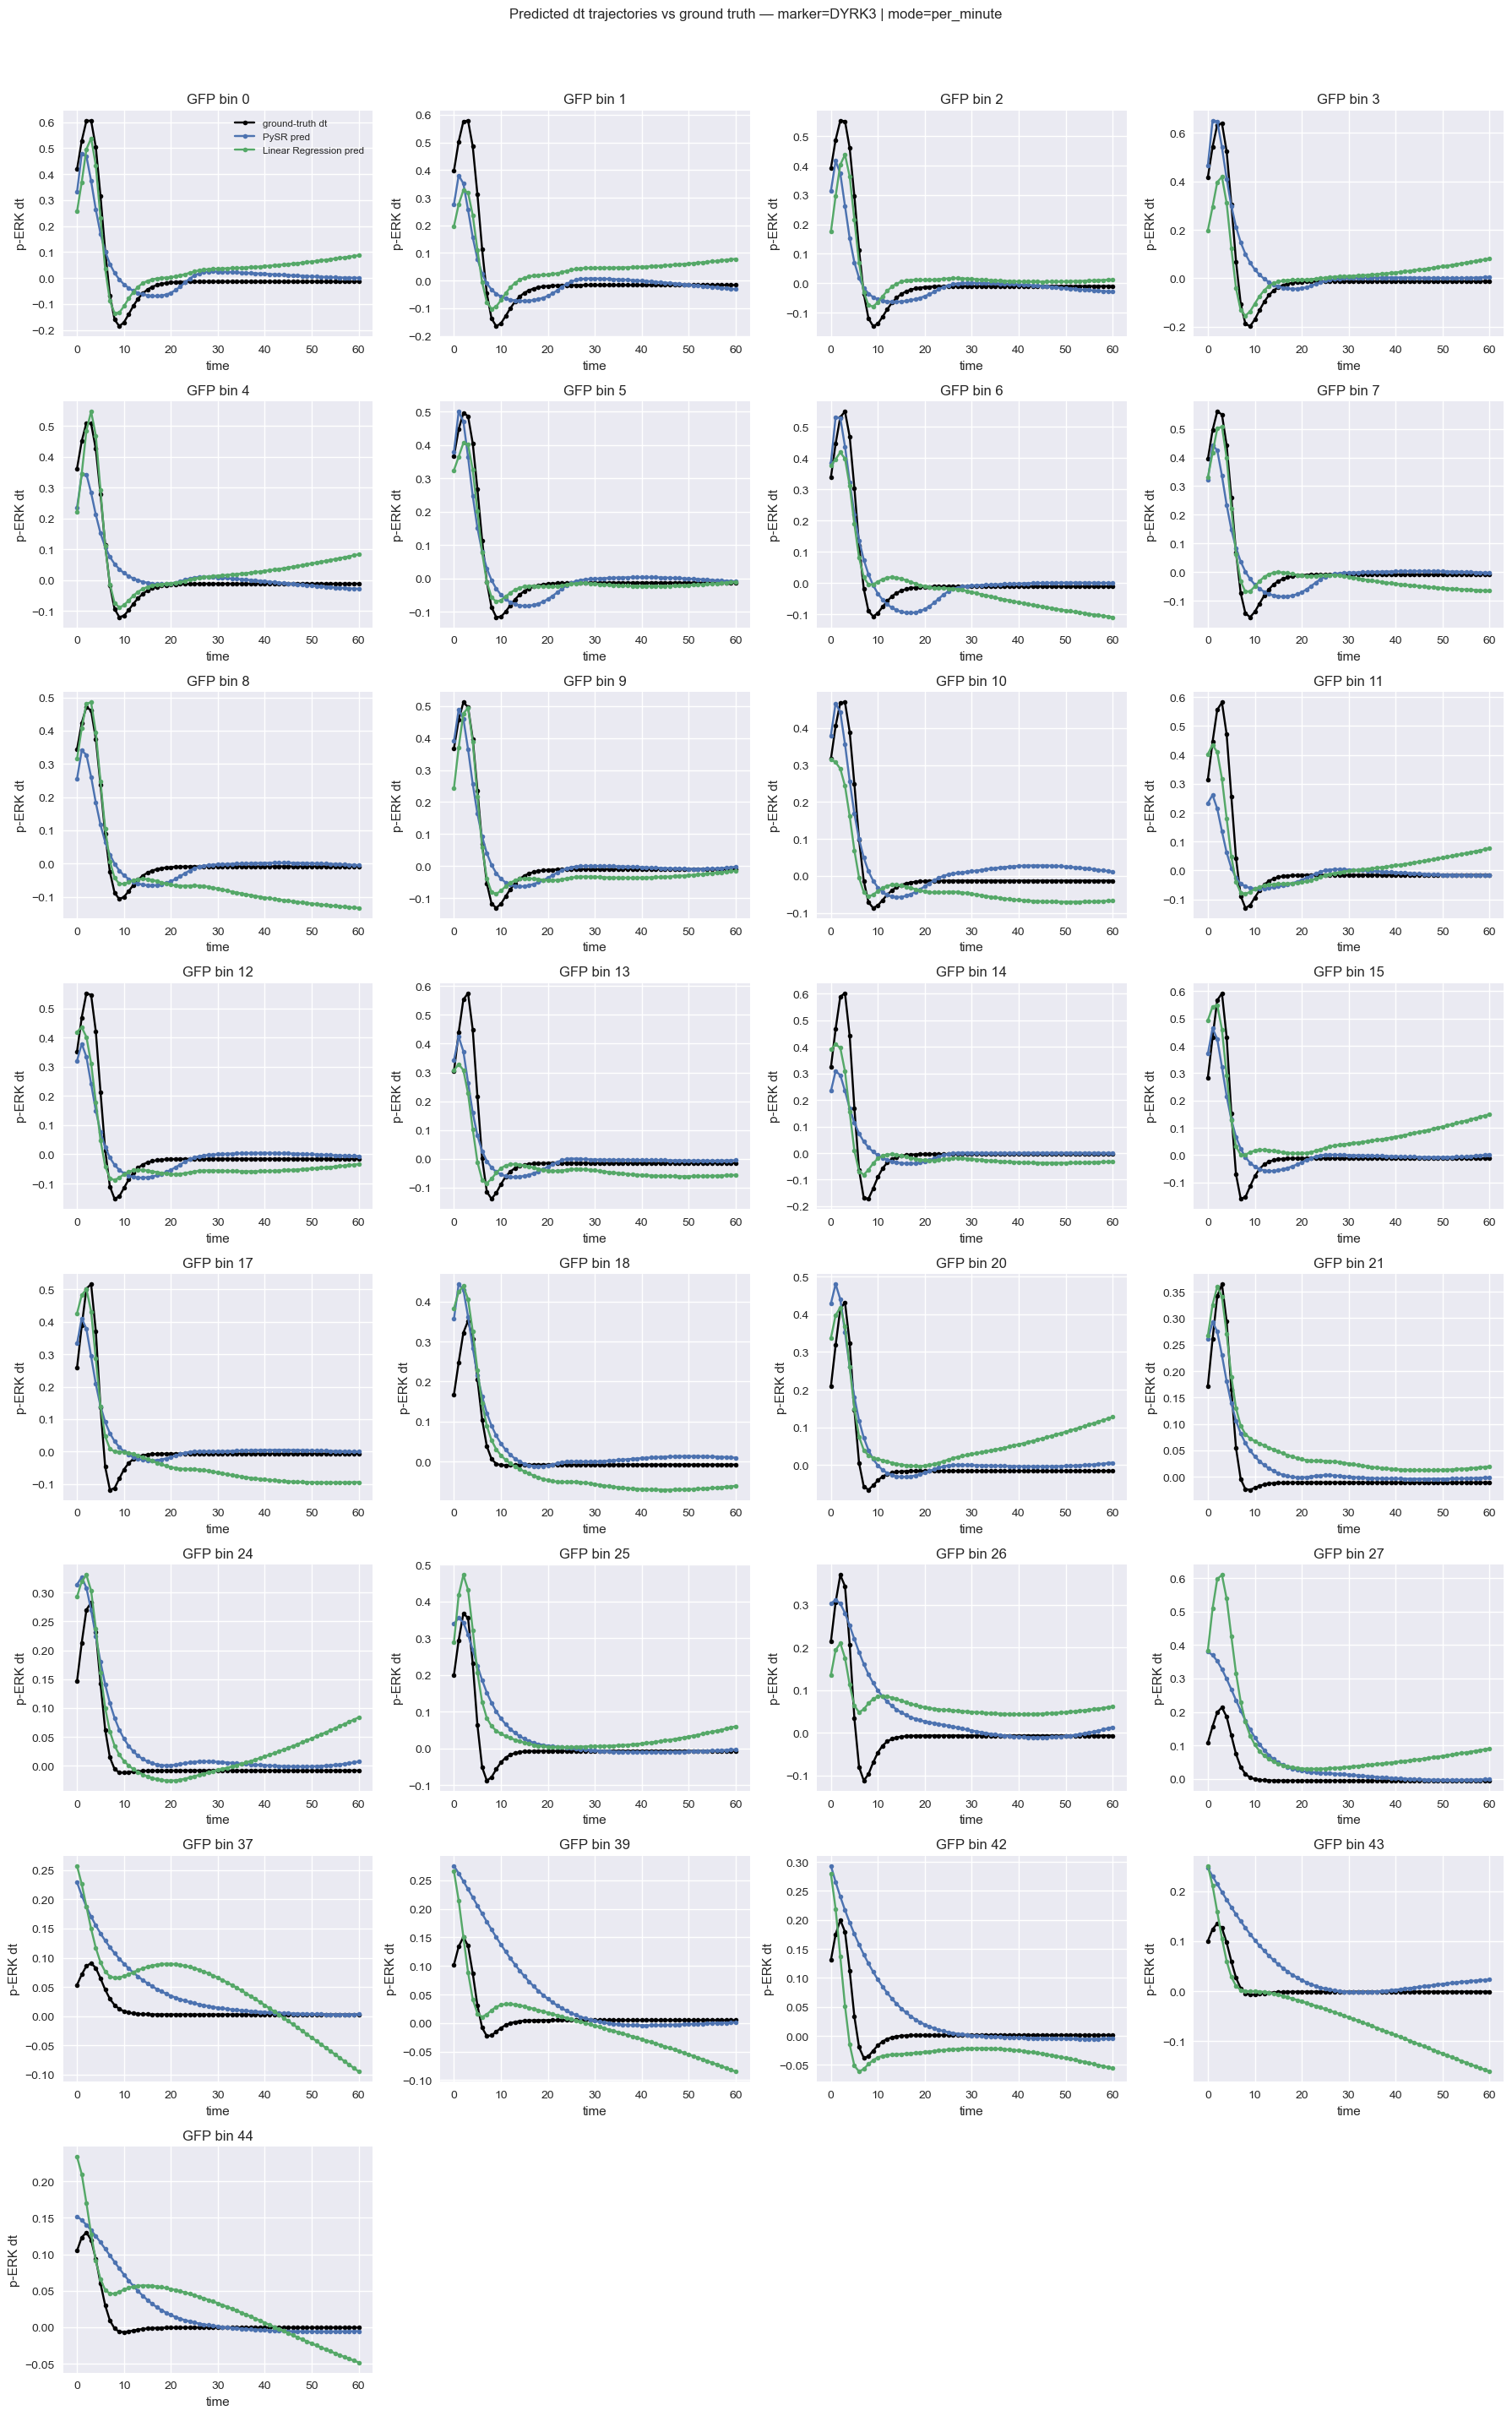

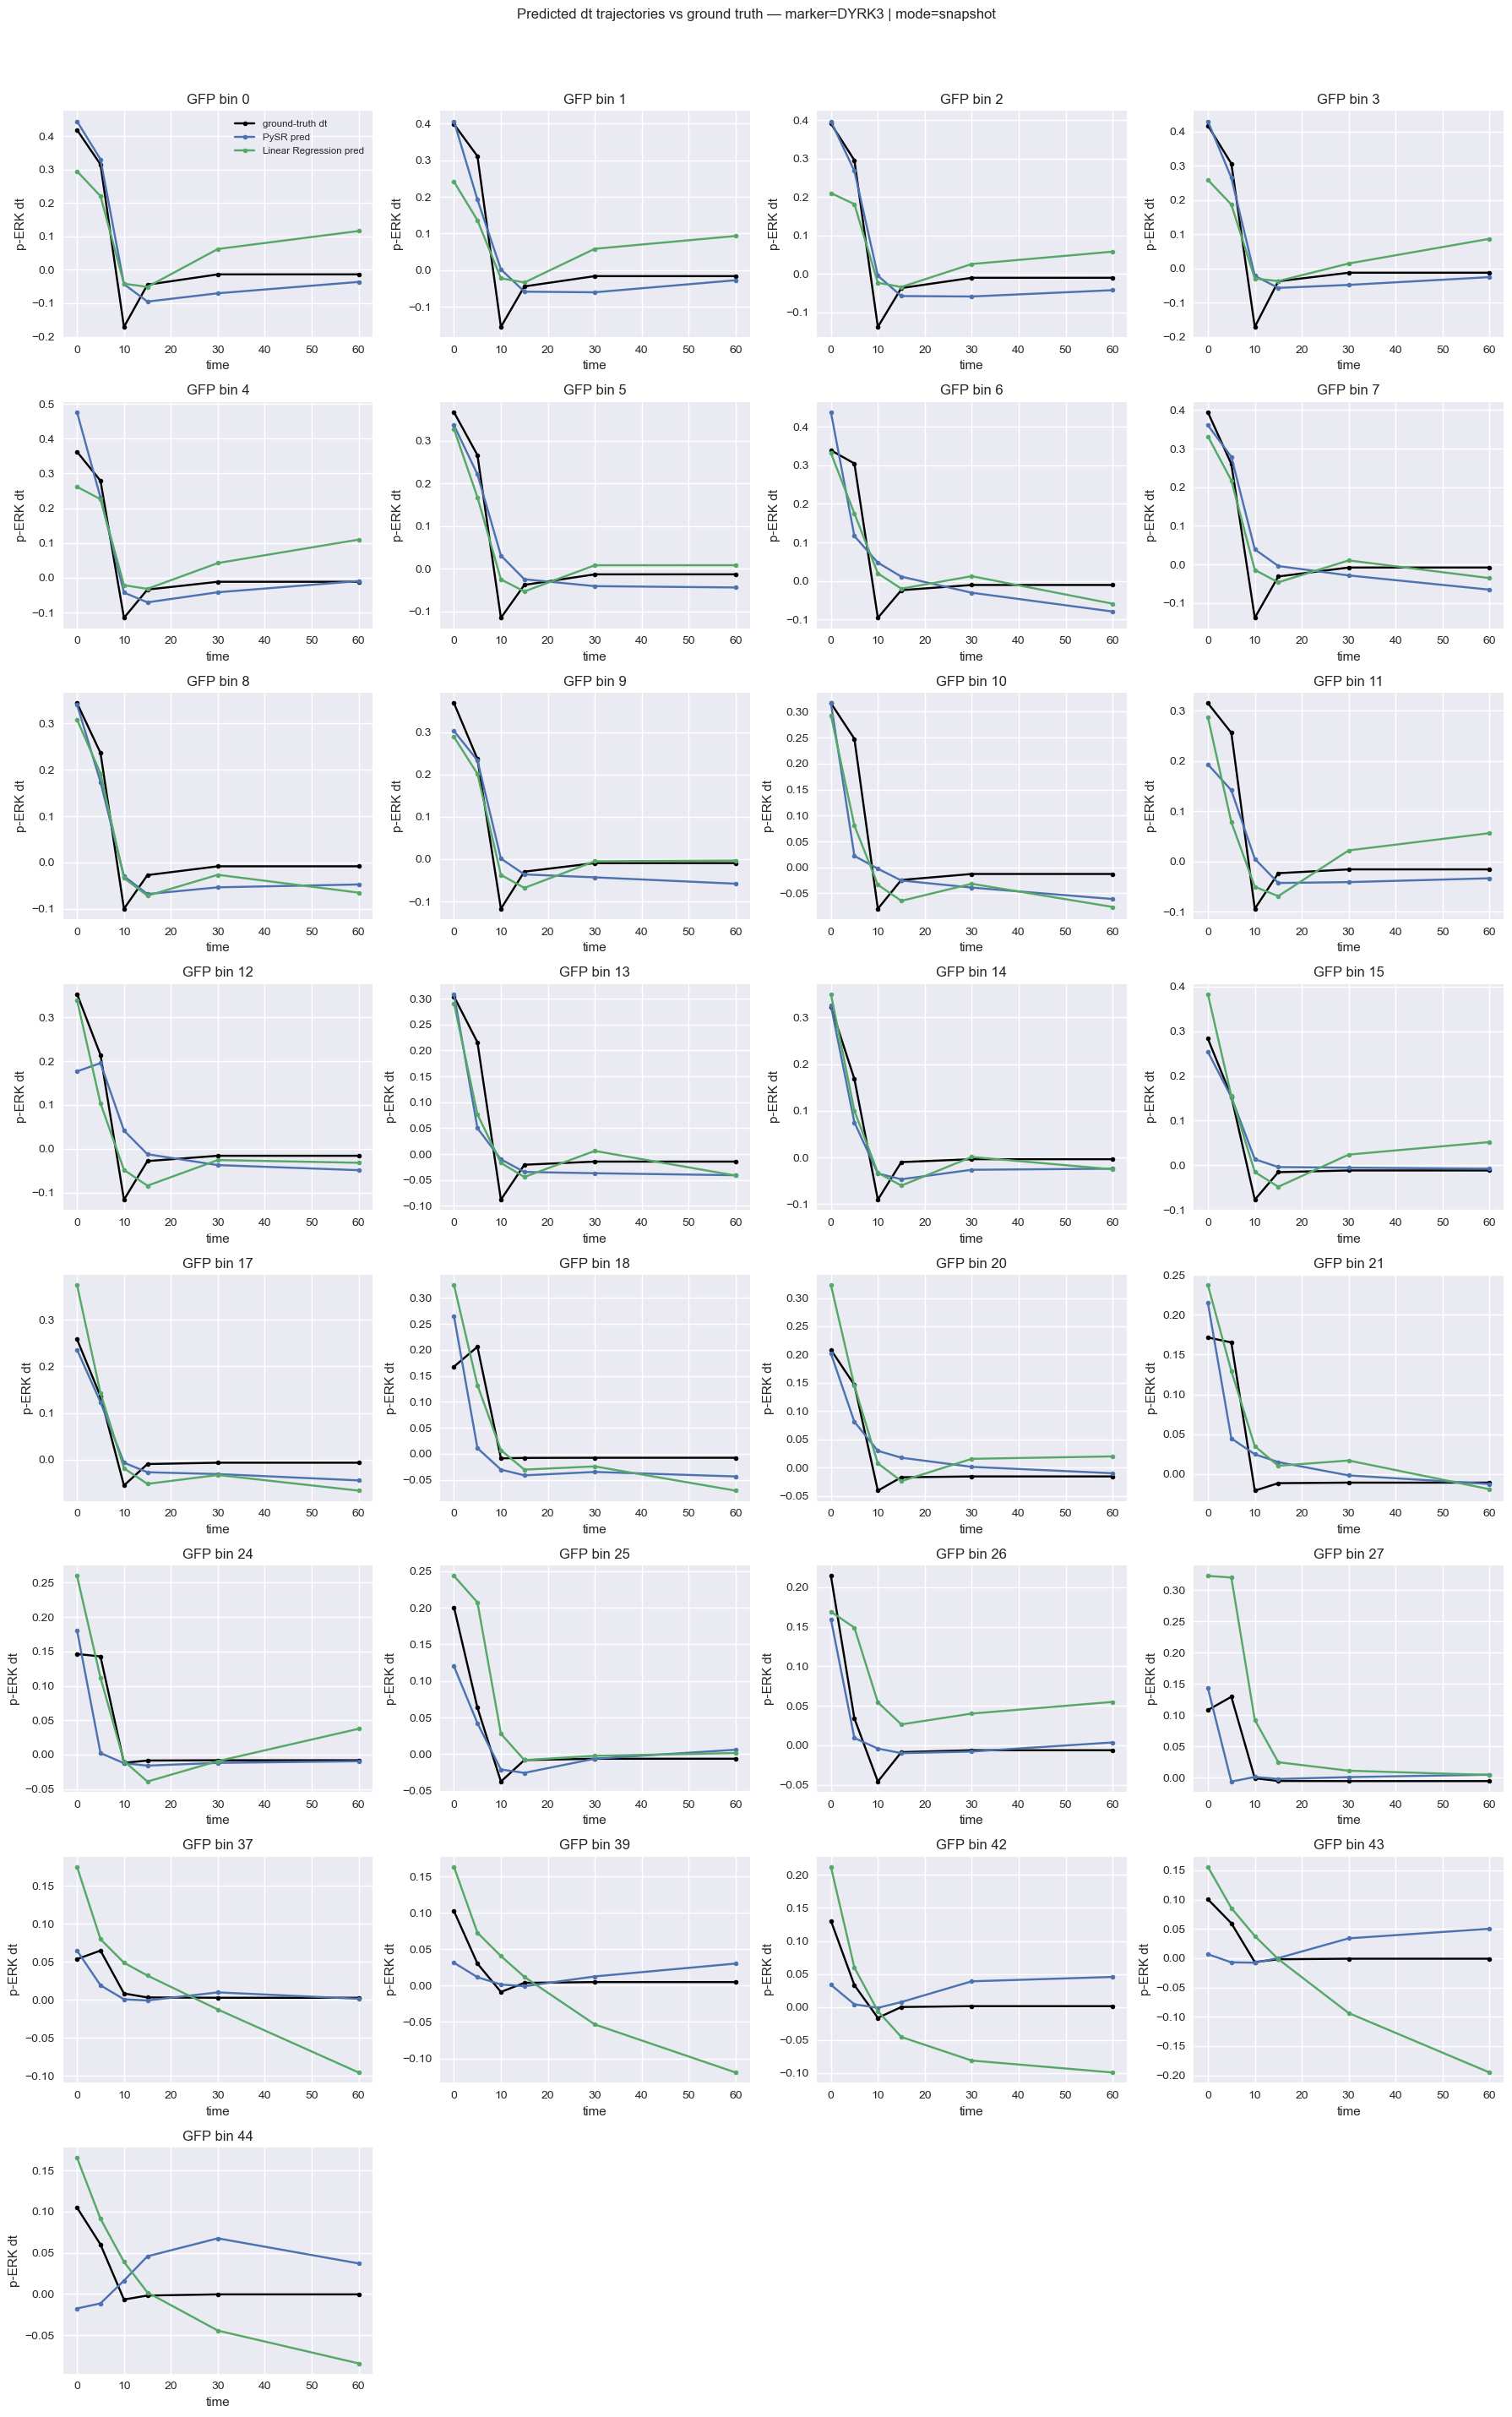

In [ ]:
# overlay predicted dt trajectories per GFP bin for two models + ground truth
def plot_dt_predictions_by_bin(
    marker=MARKER,
    dataset_modes=("per_minute", "snapshot"),
    models=("PySR", "Linear Regression"),
    max_bins=None,  # limit number of bins to plot (None -> all)
    cols=4,
    figsize_per_plot=(4.5, 3.5),
):
    for dataset_mode in dataset_modes:
        # prepare data
        df, target_col = prepare_dataset(DATASET_PATHS[dataset_mode])
        sub = df[df["marker"] == marker].dropna(subset=[target_col, "timepoint", "GFP_bin"]).copy()
        if sub.empty:
            print(f"No data for marker={marker} in dataset_mode={dataset_mode}")
            continue

        # evaluate predictions for each requested model
        pred_cols = {}
        for model in models:
            try:
                formula = load_formula(SUMMARY_PATH, marker, model, dataset_mode)
            except Exception as exc:
                print(f"Skipping model {model} for mode {dataset_mode}: {exc}")
                continue
            features = sub[[c for c in sub.columns if c not in EXCLUDE_COLUMNS and c != target_col]].copy()
            preds = evaluate_formula(formula, features)
            colname = f"pred_dt_{model.replace(' ', '_')}"
            sub[colname] = preds
            pred_cols[model] = colname

        if not pred_cols:
            print(f"No model predictions available for dataset_mode={dataset_mode}")
            continue

        bins = sorted(sub["GFP_bin"].dropna().unique())
        if max_bins is not None:
            bins = bins[:max_bins]
        n = len(bins)
        rows = int(np.ceil(n / cols))
        fig_w = cols * figsize_per_plot[0]
        fig_h = rows * figsize_per_plot[1]
        fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h), squeeze=False)
        axes_list = axes.ravel()

        for ax in axes_list[n:]:
            ax.axis("off")

        for i, g in enumerate(bins):
            ax = axes_list[i]
            gdf = sub[sub["GFP_bin"] == g].sort_values("timepoint")
            t = gdf["timepoint"].to_numpy(dtype=float)
            # ground truth dt
            gt = pd.to_numeric(gdf[target_col], errors="coerce").to_numpy(dtype=float)
            ax.plot(t, gt, "o-", color="black", label="ground-truth dt", markersize=4)

            # model preds
            for model, col in pred_cols.items():
                arr = pd.to_numeric(gdf[col], errors="coerce").to_numpy(dtype=float)
                ax.plot(t, arr, "-o", label=f"{model} pred", markersize=4)

            ax.set_title(f"GFP bin {g}")
            ax.set_xlabel("time")
            ax.set_ylabel("p-ERK dt")
            ax.grid(True)
            if i == 0:
                ax.legend(fontsize="small")

        plt.suptitle(f"Predicted dt trajectories vs ground truth — marker={marker} | mode={dataset_mode}", y=1.02)
        plt.tight_layout()
        plt.show()

# call the plotting helper for per_minute and snapshot modes
plot_dt_predictions_by_bin(marker=MARKER, dataset_modes=("per_minute", "snapshot"), models=("PySR", "Linear Regression"))

In [ ]:
# plot dt vs p-ERK (perk) per GFP bin for two models + ground truth
def plot_dt_vs_p_by_bin(
    marker=MARKER,
    dataset_modes=("per_minute", "snapshot"),
    models=("PySR", "Linear Regression"),
    max_bins=None,
    cols=4,
    figsize_per_plot=(4.5, 3.5),
):
    for dataset_mode in dataset_modes:
        df, target_col = prepare_dataset(DATASET_PATHS[dataset_mode])
        sub = df[df["marker"] == marker].dropna(subset=[target_col, "timepoint", "GFP_bin", "p_ERK1_2"]).copy()
        if sub.empty:
            print(f"No data for marker={marker} in dataset_mode={dataset_mode}")
            continue

        pred_cols = {}
        for model in models:
            try:
                formula = load_formula(SUMMARY_PATH, marker, model, dataset_mode)
            except Exception as exc:
                print(f"Skipping model {model} for mode {dataset_mode}: {exc}")
                continue
            features = sub[[c for c in sub.columns if c not in EXCLUDE_COLUMNS and c != target_col]].copy()
            preds = evaluate_formula(formula, features)
            colname = f"pred_dt_{model.replace(' ', '_')}"
            sub[colname] = preds
            pred_cols[model] = colname

        if not pred_cols:
            print(f"No model predictions available for dataset_mode={dataset_mode}")
            continue

        bins = sorted(sub["GFP_bin"].dropna().unique())
        if max_bins is not None:
            bins = bins[:max_bins]
        n = len(bins)
        rows = int(np.ceil(n / cols))
        fig_w = cols * figsize_per_plot[0]
        fig_h = rows * figsize_per_plot[1]
        fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h), squeeze=False)
        axes_list = axes.ravel()

        for ax in axes_list[n:]:
            ax.axis("off")

        for i, g in enumerate(bins):
            ax = axes_list[i]
            gdf = sub[sub["GFP_bin"] == g].sort_values("timepoint")
            t = gdf["timepoint"].to_numpy(dtype=float)
            p = pd.to_numeric(gdf["p_ERK1_2"], errors="coerce").to_numpy(dtype=float)
            gt = pd.to_numeric(gdf[target_col], errors="coerce").to_numpy(dtype=float)

            # plot ground-truth dt connected in time order
            mask_gt = np.isfinite(p) & np.isfinite(gt) & np.isfinite(t)
            if mask_gt.sum() > 0:
                order_gt = np.argsort(t[mask_gt])
                ax.plot(p[mask_gt][order_gt], gt[mask_gt][order_gt], "o-", color="black", label="ground-truth dt", markersize=4)

            # model preds: connect points in time order (trajectory)
            for model, col in pred_cols.items():
                arr = pd.to_numeric(gdf[col], errors="coerce").to_numpy(dtype=float)
                mask = np.isfinite(p) & np.isfinite(arr) & np.isfinite(t)
                if mask.sum() == 0:
                    continue
                order = np.argsort(t[mask])
                ax.plot(p[mask][order], arr[mask][order], "-o", label=f"{model} pred", markersize=4, alpha=0.8)

            ax.set_title(f"GFP bin {g}")
            ax.set_xlabel("p-ERK (p_ERK1_2)")
            ax.set_ylabel("p-ERK dt")
            ax.grid(True)
            if i == 0:
                ax.legend(fontsize="small")

        plt.suptitle(f"Predicted dt vs p-ERK — marker={marker} | mode={dataset_mode}", y=1.02)
        plt.tight_layout()
        plt.show()

# call the new plotting helper
plot_dt_vs_p_by_bin(marker=MARKER, dataset_modes=("per_minute", "snapshot"), models=("PySR", "Linear Regression"))

# textual summary printout
dataset_modes = ("per_minute", "snapshot")
models = ("PySR", "Linear Regression")

print("=== Dataset & model summary ===")
for dataset_mode in dataset_modes:
    try:
        df_mode, target_col = prepare_dataset(DATASET_PATHS[dataset_mode])
    except Exception as exc:
        print(f"{dataset_mode}: failed to load dataset: {exc}")
        continue

    sub = df_mode[df_mode["marker"] == MARKER].dropna(subset=[target_col, "timepoint", "GFP_bin"]).copy()
    n_rows = len(sub)
    n_bins = int(sub["GFP_bin"].nunique()) if n_rows > 0 else 0
    print(f"\nMode: {dataset_mode} | rows: {n_rows} | GFP bins: {n_bins} | target_col: {target_col}")

    for model in models:
        try:
            formula = load_formula(SUMMARY_PATH, MARKER, model, dataset_mode)
        except Exception as exc:
            print(f"  {model}: no formula available ({exc})")
            continue
        features = sub[[c for c in sub.columns if c not in EXCLUDE_COLUMNS and c != target_col]].copy()
        preds = evaluate_formula(formula, features)
        dt_r2 = compute_dt_r2(sub, preds, target_col, MEASURED_TIMEPOINTS, dataset_mode)
        print(f"  {model}: dt R² = {np.nan if dt_r2 is None else dt_r2:.4f} | formula: {formula}")

# print per-bin summary of plotted data + per-model per-bin R²
def _r2_score(y_true, y_pred):
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    yt = y_true[mask]
    yp = y_pred[mask]
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.nanmean(yt)) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot != 0 else np.nan

print("\n=== Per-bin plot summary ===")
for dataset_mode in dataset_modes:
    try:
        df_mode, target_col = prepare_dataset(DATASET_PATHS[dataset_mode])
    except Exception as exc:
        print(f"{dataset_mode}: failed to load dataset: {exc}")
        continue

    sub = df_mode[df_mode["marker"] == MARKER].dropna(subset=[target_col, "timepoint", "GFP_bin", "p_ERK1_2"]).copy()
    if sub.empty:
        print(f"{dataset_mode}: no data for marker={MARKER}")
        continue

    bins = sorted(sub["GFP_bin"].unique())
    print(f"\nMode: {dataset_mode} | marker={MARKER} | rows={len(sub)} | bins={len(bins)}")
    for b in bins:
        bdf = sub[sub["GFP_bin"] == b].sort_values("timepoint")
        n_pts = len(bdf)
        y_true = pd.to_numeric(bdf[target_col], errors="coerce").to_numpy(dtype=float)
        pvals = pd.to_numeric(bdf["p_ERK1_2"], errors="coerce").to_numpy(dtype=float)
        print(f"  GFP bin {b}: n={n_pts}")
        # ground-truth trajectory existence
        gt_mask = np.isfinite(pvals) & np.isfinite(y_true)
        print(f"    ground-truth points (p_ERK & target finite): {gt_mask.sum()}")
        for model in models:
            try:
                formula = load_formula(SUMMARY_PATH, MARKER, model, dataset_mode)
            except Exception as exc:
                print(f"    {model}: no formula ({exc})")
                continue
            features = bdf[[c for c in bdf.columns if c not in EXCLUDE_COLUMNS and c != target_col]].copy()
            try:
                preds = evaluate_formula(formula, features)
            except Exception as exc:
                print(f"    {model}: failed to evaluate formula ({exc})")
                continue
            preds = pd.to_numeric(preds, errors="coerce").to_numpy(dtype=float)
            r2 = _r2_score(y_true, preds)
            print(f"    {model}: n_pred_finite={np.isfinite(preds).sum()} | dt R² (per-bin) = {np.nan if r2 is None else r2:.4f}")
        # small spacer per bin
    # overall per-model R² on this dataset/maker (all bins combined)
    print(f"\n  Overall per-model R² (all bins combined) for mode={dataset_mode}:")
    for model in models:
        try:
            formula = load_formula(SUMMARY_PATH, MARKER, model, dataset_mode)
        except Exception as exc:
            print(f"    {model}: no formula ({exc})")
            continue
        features = sub[[c for c in sub.columns if c not in EXCLUDE_COLUMNS and c != target_col]].copy()
        try:
            preds = evaluate_formula(formula, features)
        except Exception as exc:
            print(f"    {model}: failed to evaluate formula ({exc})")
            continue
        y_true_all = pd.to_numeric(sub[target_col], errors="coerce").to_numpy(dtype=float)
        preds_all = pd.to_numeric(preds, errors="coerce").to_numpy(dtype=float)
        r2_all = _r2_score(y_true_all, preds_all)
        print(f"    {model}: dt R² (all bins) = {np.nan if r2_all is None else r2_all:.4f} | formula: {formula}")

Skipping model PySR for mode per_minute: [Errno 2] No such file or directory: '../data/experimental/functional_groups/outputs/reports/summary/functional_group_summary.csv'
Skipping model Linear Regression for mode per_minute: [Errno 2] No such file or directory: '../data/experimental/functional_groups/outputs/reports/summary/functional_group_summary.csv'
No model predictions available for dataset_mode=per_minute
Skipping model PySR for mode snapshot: [Errno 2] No such file or directory: '../data/experimental/functional_groups/outputs/reports/summary/functional_group_summary.csv'
Skipping model Linear Regression for mode snapshot: [Errno 2] No such file or directory: '../data/experimental/functional_groups/outputs/reports/summary/functional_group_summary.csv'
No model predictions available for dataset_mode=snapshot
=== Dataset & model summary ===

Mode: per_minute | rows: 1769 | GFP bins: 29 | target_col: p_ERK1_2_dt
  PySR: no formula available ([Errno 2] No such file or directory: '..

In [ ]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import numpy as _np
import pandas as _pd

import matplotlib.cm as cm

def compute_directional_slopes(p, dt, t=None):
    # ensure arrays and time-ordering if provided
    p = np.asarray(p, dtype=float)
    dt = np.asarray(dt, dtype=float)
    if t is None:
        order = np.argsort(np.arange(len(p)))
    else:
        t = np.asarray(t, dtype=float)
        order = np.argsort(t)
    p, dt = p[order], dt[order]
    valid = np.isfinite(p) & np.isfinite(dt)
    if valid.sum() < 2:
        return None
    p, dt = p[valid], dt[valid]
    dp = np.diff(p)
    ddt = np.diff(dt)
    mask = (dp != 0) & np.isfinite(ddt)
    if mask.sum() == 0:
        return None
    slopes = ddt[mask] / dp[mask]
    seg_p_mid = (p[:-1] + p[1:]) / 2.0
    seg_pts = np.stack([np.column_stack([p[:-1], dt[:-1]]), np.column_stack([p[1:], dt[1:]])], axis=1)
    segs = seg_pts[mask]
    return {"slopes": slopes, "segs": segs, "mid_p": seg_p_mid[mask], "p": p, "dt": dt}

def plot_directional_slope_by_bin(
    marker=MARKER,
    dataset_modes=("per_minute", "snapshot"),
    models=("PySR", "Linear Regression"),
    max_bins=8,
    cols=3,
    figsize_per_plot=(4, 3),
):
    for dataset_mode in dataset_modes:
        df, target_col = prepare_dataset(DATASET_PATHS[dataset_mode])
        sub = df[df["marker"] == marker].dropna(subset=[target_col, "timepoint", "GFP_bin"]).copy()
        if sub.empty:
            print(f"No data for marker={marker} in mode={dataset_mode}")
            continue

        # evaluate model preds
        pred_cols = {}
        for model in models:
            try:
                formula = load_formula(SUMMARY_PATH, marker, model, dataset_mode)
            except Exception as exc:
                print(f"skip {model} in {dataset_mode}: {exc}")
                continue
            features = sub[[c for c in sub.columns if c not in EXCLUDE_COLUMNS and c != target_col]].copy()
            sub[f"pred_dt_{model.replace(' ', '_')}"] = evaluate_formula(formula, features)
            pred_cols[model] = f"pred_dt_{model.replace(' ', '_')}"

        if not pred_cols:
            print(f"No predictions available for {dataset_mode}")
            continue

        bins = sorted(sub["GFP_bin"].dropna().unique())
        if max_bins is not None:
            bins = bins[:max_bins]
        n = len(bins)
        rows = n
        cols_fig = 1 + len(pred_cols)  # one column for ground-truth + one per model
        fig_w = cols_fig * figsize_per_plot[0]
        fig_h = rows * figsize_per_plot[1]
        fig, axes = plt.subplots(rows, cols_fig, figsize=(fig_w, fig_h), squeeze=False)

        cmap = cm.get_cmap("RdBu_r")
        for i, g in enumerate(bins):
            gdf = sub[sub["GFP_bin"] == g].sort_values("timepoint")
            t = gdf["timepoint"].to_numpy(dtype=float)
            p = pd.to_numeric(gdf["p_ERK1_2"], errors="coerce").to_numpy(dtype=float)
            # ground truth
            gt_dt = pd.to_numeric(gdf[target_col], errors="coerce").to_numpy(dtype=float)
            slots = [("GT", p, gt_dt)]
            for model, col in pred_cols.items():
                slots.append((model, p, pd.to_numeric(gdf[col], errors="coerce").to_numpy(dtype=float)))

            # compute slopes across all slots to set color scale
            all_slopes = []
            results = {}
            for name, pp, ddt in slots:
                res = compute_directional_slopes(pp, ddt, t)
                results[name] = res
                if res is not None:
                    all_slopes.append(res["slopes"])
            if all_slopes:
                all_slopes = np.concatenate(all_slopes)
                vmax = np.nanpercentile(np.abs(all_slopes), 95)
                if vmax == 0:
                    vmax = 1.0
                norm = Normalize(vmin=-vmax, vmax=vmax)
            else:
                norm = Normalize(vmin=-1.0, vmax=1.0)

            for j, (name, pp, ddt) in enumerate(slots):
                ax = axes[i, j]
                res = results[name]
                ax.set_title(f"GFP {g} | {name}")
                ax.set_xlabel("p-ERK (p_ERK1_2)")
                ax.set_ylabel("p-ERK dt")
                ax.grid(True)
                # plot points
                ax.plot(pp, ddt, "o-", color="0.25", markersize=3, alpha=0.6)
                if res is not None:
                    lc = LineCollection(res["segs"], cmap=cmap, norm=norm, linewidths=2)
                    lc.set_array(res["slopes"])
                    ax.add_collection(lc)
                    # annotate stats
                    med = np.median(res["slopes"])
                    pct_neg = 100.0 * np.mean(res["slopes"] < 0)
                    ax.text(0.02, 0.95, f"med slope={med:.3g}\n%neg={pct_neg:.0f}%", transform=ax.transAxes,
                            va="top", ha="left", fontsize="small", bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
                else:
                    ax.text(0.5, 0.5, "no valid slope", transform=ax.transAxes, ha="center", va="center")

        # single colorbar for the figure
        cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        cb = cm.ScalarMappable(norm=norm, cmap=cmap)
        fig.colorbar(cb, cax=cax, label="directional slope (d dt / d p)")
        plt.suptitle(f"Directional slope along trajectory — marker={marker} | mode={dataset_mode}", y=0.98)
        plt.tight_layout(rect=[0, 0, 0.9, 0.96])
        plt.show()

# call for both dataset modes, limit bins to keep plots readable
plot_directional_slope_by_bin(marker=MARKER, dataset_modes=("per_minute", "snapshot"), models=("PySR", "Linear Regression"), max_bins=6)

# Hyper-detailed textual summary for the directional-slope plots
def summarize_directional_plots(df=None, target_col=None, pred_prefixes=("pred_dt_", "__y_pred_dt"), max_bins=None):

    # choose dataframe and target column from existing vars if not provided
    if df is None:
        if "sub_df" in globals():
            df = globals()["sub_df"]
        elif "sub" in globals():
            df = globals()["sub"]
        else:
            raise RuntimeError("No dataframe found (provide df or define sub/sub_df in the notebook).")
    if target_col is None:
        if "target_col" in globals():
            target_col = globals()["target_col"]
        elif "target_col_grid" in globals():
            target_col = globals()["target_col_grid"]
        else:
            raise RuntimeError("No target_col found (provide target_col or define target_col in the notebook).")

    # find prediction columns
    pred_cols = [c for c in df.columns if any(c.startswith(pref) for pref in pred_prefixes)]
    # also accept columns named like 'pred_dt_ModelName' even if different prefix
    pred_cols += [c for c in df.columns if c.startswith("pred_dt_") and c not in pred_cols]
    pred_cols = sorted(set(pred_cols))

    total_rows = len(df)
    bins = sorted(df["GFP_bin"].dropna().unique())
    if max_bins is not None:
        bins = bins[:max_bins]

    header = []
    header.append("=== Directional-slope plots summary ===")
    header.append(f"Source rows: {total_rows}")
    header.append(f"Target column: {target_col}")
    header.append(f"Prediction columns found: {pred_cols if pred_cols else 'NONE'}")
    header.append(f"Number of GFP bins to summarize: {len(bins)}")
    print("\n".join(header))
    print("")

    # compute global slope distribution to contextualize color mapping
    global_slopes = []
    for g in bins:
        gdf = df[df["GFP_bin"] == g].sort_values("timepoint")
        t = gdf["timepoint"].to_numpy(dtype=float)
        p = _pd.to_numeric(gdf["p_ERK1_2"], errors="coerce").to_numpy(dtype=float)
        gt = _pd.to_numeric(gdf[target_col], errors="coerce").to_numpy(dtype=float)
        res = compute_directional_slopes(p, gt, t)
        if res is not None:
            global_slopes.append(res["slopes"])
        for col in pred_cols:
            preds = _pd.to_numeric(gdf[col], errors="coerce").to_numpy(dtype=float)
            res2 = compute_directional_slopes(p, preds, t)
            if res2 is not None:
                global_slopes.append(res2["slopes"])
    if global_slopes:
        global_slopes = _np.concatenate(global_slopes)
        gv95 = _np.nanpercentile(_np.abs(global_slopes), 95)
        gvmax = gv95 if gv95 > 0 else _np.nanmax(_np.abs(global_slopes))
    else:
        global_slopes = _np.array([])
        gv95 = 0.0
        gvmax = 1.0

    print(f"Global slope magnitude 95th percentile (used for color scaling in plots): {gv95:.6g}")
    print(f"Global slope min/median/max (abs): {(_np.nanmin(_np.abs(global_slopes)) if global_slopes.size else 'n/a')} / {(_np.nanmedian(_np.abs(global_slopes)) if global_slopes.size else 'n/a')} / {(_np.nanmax(_np.abs(global_slopes)) if global_slopes.size else 'n/a')}")
    print("")

    # per-bin detailed stats
    for g in bins:
        gdf = df[df["GFP_bin"] == g].sort_values("timepoint")
        n_pts = len(gdf)
        p = _pd.to_numeric(gdf["p_ERK1_2"], errors="coerce").to_numpy(dtype=float)
        t = gdf["timepoint"].to_numpy(dtype=float)
        gt = _pd.to_numeric(gdf[target_col], errors="coerce").to_numpy(dtype=float)

        print(f"--- GFP bin {g} (rows: {n_pts}) ---")
        # quick time / signal diagnostics
        t_span = (float(_np.nanmin(t)), float(_np.nanmax(t))) if n_pts > 0 else (None, None)
        p_range = (float(_np.nanmin(p)), float(_np.nanmax(p))) if _np.isfinite(p).any() else (None, None)
        dt_range = (float(_np.nanmin(gt)), float(_np.nanmax(gt))) if _np.isfinite(gt).any() else (None, None)
        print(f"Time span: {t_span[0]} → {t_span[1]} | p range: {p_range[0]:.6g} → {p_range[1]:.6g} | target dt range: {dt_range[0]:.6g} → {dt_range[1]:.6g}")

        # slots: ground-truth + each model
        slots = [("GT", p, gt)] + [(col.replace("pred_dt_", "").replace("__y_pred_dt", "__y_pred_dt"), p, _pd.to_numeric(gdf[col], errors="coerce").to_numpy(dtype=float)) for col in pred_cols]

        # collect slopes across slots for this bin
        bin_slopes = []
        slot_results = {}
        for name, pp, ddt in slots:
            res = compute_directional_slopes(pp, ddt, t)
            slot_results[name] = res
            if res is not None:
                s = res["slopes"]
                bin_slopes.append(s)

        # color scale for this bin
        if bin_slopes:
            bin_slopes = _np.concatenate(bin_slopes)
            bin_v95 = _np.nanpercentile(_np.abs(bin_slopes), 95)
            bin_vmax = bin_v95 if bin_v95 > 0 else (_np.nanmax(_np.abs(bin_slopes)) if bin_slopes.size else 1.0)
        else:
            bin_vmax = 1.0

        print(f"Color-scale vmax (per-bin 95th abs percentile): {bin_vmax:.6g}")

        # show detailed stats per slot
        for name, pp, ddt in slots:
            res = slot_results[name]
            label = name
            if res is None:
                print(f"  {label}: NO valid slope segments (insufficient finite consecutive points or zero dp).")
                continue
            slopes = res["slopes"]
            n_segs = slopes.size
            med = float(_np.nanmedian(slopes))
            mean = float(_np.nanmean(slopes))
            std = float(_np.nanstd(slopes))
            pct_neg = 100.0 * float(_np.mean(slopes < 0))
            pct_pos = 100.0 * float(_np.mean(slopes > 0))
            q25, q75 = float(_np.nanpercentile(slopes, 25)), float(_np.nanpercentile(slopes, 75))
            slo_min, slo_max = float(_np.nanmin(slopes)), float(_np.nanmax(slopes))
            # mid_p distribution for segments
            midp = res.get("mid_p", _np.array([]))
            midp_q = (float(_np.nanpercentile(midp, 5)), float(_np.nanpercentile(midp, 50)), float(_np.nanpercentile(midp, 95))) if midp.size else (None, None, None)
            # segment endpoint ranges
            p_endpoints = res.get("p", _np.array([]))
            dt_endpoints = res.get("dt", _np.array([]))
            p_ep_range = (float(_np.nanmin(p_endpoints)), float(_np.nanmax(p_endpoints))) if p_endpoints.size else (None, None)
            dt_ep_range = (float(_np.nanmin(dt_endpoints)), float(_np.nanmax(dt_endpoints))) if dt_endpoints.size else (None, None)

            print(f"  {label}: segments={n_segs} | median={med:.6g} | mean={mean:.6g} | std={std:.6g} | min={slo_min:.6g} | max={slo_max:.6g}")
            print(f"     interquartile: Q1={q25:.6g} | Q3={q75:.6g} | %neg={pct_neg:.1f}% | %pos={pct_pos:.1f}%")
            print(f"     mid-p (5/50/95%): {midp_q} | p endpoints range: {p_ep_range} | dt endpoints range: {dt_ep_range}")
            # check for extreme slopes relative to global vmax
            if gvmax and _np.isfinite(gvmax) and abs(med) > 2.0 * gvmax:
                print("     NOTE: median slope magnitude >> global color-scale vmax (outlier behavior).")
            if n_segs < 3:
                print("     NOTE: very few slope segments — trajectory-derived statistics may be noisy.")
        print("")

    # overall summary across all bins
    all_slot_stats = {}
    for label in ["GT"] + [c.replace("pred_dt_", "").replace("__y_pred_dt", "__y_pred_dt") for c in pred_cols]:
        all_sl = []
        for g in bins:
            gdf = df[df["GFP_bin"] == g].sort_values("timepoint")
            t = gdf["timepoint"].to_numpy(dtype=float)
            p = _pd.to_numeric(gdf["p_ERK1_2"], errors="coerce").to_numpy(dtype=float)
            if label == "GT":
                ddt = _pd.to_numeric(gdf[target_col], errors="coerce").to_numpy(dtype=float)
            else:
                # recover column name by reversing the transformation
                colname = label if label.startswith("__y_pred") else f"pred_dt_{label}"
                if colname in gdf.columns:
                    ddt = _pd.to_numeric(gdf[colname], errors="coerce").to_numpy(dtype=float)
                else:
                    ddt = None
            if ddt is None:
                continue
            res = compute_directional_slopes(p, ddt, t)
            if res is not None:
                all_sl.append(res["slopes"])
        if all_sl:
            all_sl = _np.concatenate(all_sl)
            all_slot_stats[label] = {
                "n_segments": int(all_sl.size),
                "median": float(_np.nanmedian(all_sl)),
                "mean": float(_np.nanmean(all_sl)),
                "std": float(_np.nanstd(all_sl)),
                "pct_neg": 100.0 * float(_np.mean(all_sl < 0)),
                "5/95_abs": (float(_np.nanpercentile(_np.abs(all_sl), 5)), float(_np.nanpercentile(_np.abs(all_sl), 95))),
            }
    print("=== Overall (all bins combined) directional-slope stats ===")
    for label, st in all_slot_stats.items():
        print(f"  {label}: segments={st['n_segments']} | median={st['median']:.6g} | mean={st['mean']:.6g} | std={st['std']:.6g} | %neg={st['pct_neg']:.1f}% | abs(5/95%)={st['5/95_abs']}")

# attempt to run summary with the available dataframe(s)
try:
    summarize_directional_plots(max_bins=6)
except Exception as exc:
    print(f"Failed to auto-summarize plots: {exc}")
    print("You can call summarize_directional_plots(df=<your_df>, target_col='<target_col>') manually.")

skip PySR in per_minute: [Errno 2] No such file or directory: '../data/experimental/functional_groups/outputs/reports/summary/functional_group_summary.csv'
skip Linear Regression in per_minute: [Errno 2] No such file or directory: '../data/experimental/functional_groups/outputs/reports/summary/functional_group_summary.csv'
No predictions available for per_minute
skip PySR in snapshot: [Errno 2] No such file or directory: '../data/experimental/functional_groups/outputs/reports/summary/functional_group_summary.csv'
skip Linear Regression in snapshot: [Errno 2] No such file or directory: '../data/experimental/functional_groups/outputs/reports/summary/functional_group_summary.csv'
No predictions available for snapshot
=== Directional-slope plots summary ===
Source rows: 1769
Target column: p_ERK1_2_dt
Prediction columns found: ['__y_pred_dt']
Number of GFP bins to summarize: 6

Global slope magnitude 95th percentile (used for color scaling in plots): 0.620862
Global slope min/median/max (a